In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> src/pipelines/04_eda_annot_gt_cycle/03_ukdale_houses_gt_cycle_eda.py.
> Edit the source and re-export; do not edit the exported notebook by hand.

# GT cycles across all UK-DALE houses: extract, verify by eye, curate

The house_1 EDA (01_ukdale_gt_cycle_eda.ipynb) established the class
split - program cycles (600 s dwell / 600 s merge), burst episodes kept
raw, fridge duty excluded - and the 20-marks-per-device curation
fallback. This notebook applies the same process to **every house in
the UK-DALE gold layer**, with one addition the house_1 round made
explicit: every candidate episode is reviewed against the **whole-house
power** (the aggregate strip under each submeter trace), so curation
picks episodes that are easy to recognize from the aggregate alone -
the deployment-time signal - not just clean on the submeter.

Three store files back this round (written by
src/pipelines/04_eda_annot_gt_cycle/02_build_rule_profiles.py, loaded
back here): splits.csv (reserved test span per house),
device_profile.csv (class, rule, measured power/energy per device) and
rule_cycles.csv (burst-device cycles). Threshold overrides and channel
exclusions below are decisions of this EDA, each with its measured
justification. All numbers provisional; nothing is a gate.

In [ ]:
# Headless rendering + shared baseline lib (same pattern as 01).
import sys
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
_here = Path(__file__).resolve()
sys.path.insert(0, str(_here.parents[2] / "experiments" / "00_baseline"))
import baseline_lib as bl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# --- Notebook parameters (provisional, stated up front) ---------------
cfg = {
    "dataset": "ukdale",
    "houses_full": ("house_2", "house_5"),  # program devices present: full treatment
    "housesbrief_h34": ("house_3", "house_4"),  # no program device: verification only
    "program": ("washing_machine", "dishwasher"),
    "burst": ("kettle", "microwave"),
    "duty": ("fridge",),
    "cycle_dwell_s": 600.0,  # program-class cycle rule (01 verdict)
    "cycle_merge_s": 600.0,
    "burst_dwell_s": 30.0,  # burst class: raw episodes
    "burst_merge_s": 60.0,
    "duty_dwell_s": 30.0,  # duty class: compressor runs (reference only)
    "duty_merge_s": 12.0,
    "cycle_like_s": 600.0,
    "cycle_like_wh": 100.0,
    "split_frac": 0.75,  # test span = tail after split (02_build_rule_profiles)
    "smooth_s": 30.0,  # aggregate activation runs (01 vocabulary)
    # per-house hysteresis: house_5 idles at ~550 W median (always-on
    # load), so the 500/200 pair from houses 1-2 never fires there.
    "hys": {"house_2": (500.0, 200.0), "house_5": (1000.0, 700.0)},
    "base_win_s": 60.0,
    "sheet_top": 30,  # review-sheet size (top calibration cycles by energy)
    "sheet_pad_s": 1200.0,  # aggregate context shown around each candidate
    "seed": 3,
}

In [ ]:
mo.md(
    "## Parameters used in this EDA\n\n"
    + bl.md_table(["parameter", "value"], [[k, v] for k, v in cfg.items()])
)

## Parameters used in this EDA

| parameter | value |
|---|---|
| dataset | ukdale |
| houses_full | ('house_2', 'house_5') |
| housesbrief_h34 | ('house_3', 'house_4') |
| program | ('washing_machine', 'dishwasher') |
| burst | ('kettle', 'microwave') |
| duty | ('fridge',) |
| cycle_dwell_s | 600.0 |
| cycle_merge_s | 600.0 |
| burst_dwell_s | 30.0 |
| burst_merge_s | 60.0 |
| duty_dwell_s | 30.0 |
| duty_merge_s | 12.0 |
| cycle_like_s | 600.0 |
| cycle_like_wh | 100.0 |
| split_frac | 0.75 |
| smooth_s | 30.0 |
| hys | {'house_2': (500.0, 200.0), 'house_5': (1000.0, 700.0)} |
| base_win_s | 60.0 |
| sheet_top | 30 |
| sheet_pad_s | 1200.0 |
| seed | 3 |

In [ ]:
# --- Load the rule-derived store files (computation) -------------------
# Written by 02_build_rule_profiles.py; this notebook verifies and
# displays them - the builder stays the single writer.
_houses = ("house_1", "house_2", "house_3", "house_4", "house_5")
splits_frames = []
for _h in _houses:
    _s = pd.read_csv(bl.gold_annot_file(cfg["dataset"], _h, "splits"))
    splits_frames.append(_s)
splits_df = pd.concat(splits_frames, ignore_index=True)

prof_frames = []
for _h in _houses:
    _p = pd.read_csv(bl.gold_annot_file(cfg["dataset"], _h, "device_profile"))
    prof_frames.append(_p)
profiles_df = pd.concat(prof_frames, ignore_index=True)

rule_rows = []
for _h in _houses:
    _path = bl.gold_annot_file(cfg["dataset"], _h, "rule_cycles")
    try:
        _rc = pd.read_csv(_path)
    except pd.errors.EmptyDataError:
        continue
    for _dev, _g in _rc.groupby("device"):
        rule_rows.append(
            {
                "house": _h,
                "device": _dev,
                "n": int(len(_g)),
                "dur_p50_min": float(_g["dur_s"].median() / 60.0),
                "energy_p50_wh": float(_g["energy_wh"].median()),
                "source": str(_g["source"].iloc[0]),
            }
        )
rule_counts_df = pd.DataFrame(rule_rows)

In [ ]:
# presentation: store tables - splits, threshold decisions, rule cycles
_sp = [
    [r.house, r.split_date_utc, r.basis] for r in splits_df.itertuples()
]
_pf = [
    [
        r["house"],
        r["device"],
        str(r["class"]),
        f"{r['thr_used_w']:.0f}",
        r["thr_source"],
        f"{r['on_power_p50_w']:.0f}" if r["on_power_p50_w"] == r["on_power_p50_w"] else "-",
        f"{r['n_cycles']:,}",
        f"{r['n_cycles_cal']:,}",
    ]
    for r in profiles_df.to_dict("records")
]
_rc = [
    [
        r.house,
        r.device,
        f"{r.n:,}",
        f"{r.dur_p50_min:.1f}",
        f"{r.energy_p50_wh:.0f}",
        r.source,
    ]
    for r in rule_counts_df.itertuples()
]
mo.md(
    "## The rule store, before any new eyeballing\n\n"
    "**Reserved test spans** (curation draws only from before the split):\n\n"
    + bl.md_table(["house", "split date (UTC)", "basis"], _sp)
    + "\n\n**Threshold decisions per device** (from device_profile.csv; "
    "thr_source says gold value vs override vs excluded - every override "
    "and exclusion is justified by measured power levels in the "
    "per-house sections below):\n\n"
    + bl.md_table(
        ["house", "device", "class", "thr used (W)", "thr source", "on-power p50 (W)", "cycles/episodes", "in cal span"],
        _pf,
    )
    + "\n\n**Burst rule cycles stored** (rule_cycles.csv, source rule_v1; "
    "program cycles are deliberately absent - they enter the store only "
    "as hand-curated marks):\n\n"
    + bl.md_table(["house", "device", "cycles", "p50 dur (min)", "p50 energy (Wh)", "source"], _rc)
 + "\n\nAlready visible from the numbers alone: house_5's microwave "
    "channel carries no appliance signal at all (constant ~50 W), and "
    "house_4's 'microwave' is a shared washing_machine + microwave + "
    "breadmaker channel - both excluded rather than curated."
)

## The rule store, before any new eyeballing

**Reserved test spans** (curation draws only from before the split):

| house | split date (UTC) | basis |
|---|---|---|
| house_1 | 2013-10-01 | established 2013-10-01 contract (01_ukdale_gt_cycle_eda) |
| house_2 | 2013-08-12 | floor to UTC midnight of t0 + 75% of mains span |
| house_3 | 2013-03-29 | floor to UTC midnight of t0 + 75% of mains span |
| house_4 | 2013-08-10 | floor to UTC midnight of t0 + 75% of mains span |
| house_5 | 2014-10-10 | floor to UTC midnight of t0 + 75% of mains span |

**Threshold decisions per device** (from device_profile.csv; thr_source says gold value vs override vs excluded - every override and exclusion is justified by measured power levels in the per-house sections below):

| house | device | class | thr used (W) | thr source | on-power p50 (W) | cycles/episodes | in cal span |
|---|---|---|---|---|---|---|---|
| house_1 | washing_machine | program | 90 | gold | 256 | 1,294 | 199 |
| house_1 | dishwasher | program | 60 | gold | 122 | 679 | 94 |
| house_1 | kettle | burst | 1173 | gold | 2348 | 6,897 | 1,138 |
| house_1 | microwave | burst | 762 | gold | 1553 | 5,047 | 775 |
| house_1 | fridge | duty | 44 | gold | 89 | 39,666 | 7,094 |
| house_2 | washing_machine | program | 81 | gold | 259 | 53 | 36 |
| house_2 | dishwasher | program | 90 | override | 1984 | 106 | 66 |
| house_2 | kettle | burst | 1477 | gold | 2954 | 757 | 522 |
| house_2 | microwave | burst | 500 | override | 1311 | 375 | 261 |
| house_2 | fridge | duty | 40 | override | 88 | 3,839 | 2,331 |
| house_3 | kettle | burst | 1475 | gold | 2952 | 55 | 34 |
| house_4 | kettle | burst | 1083 | gold | 2174 | 674 | 502 |
| house_4 | microwave | burst | 90 | excluded | - | 0 | 0 |
| house_4 | fridge | duty | 46 | gold | 91 | 4,828 | 3,907 |
| house_5 | washing_machine | program | 50 | override | 474 | 110 | 85 |
| house_5 | dishwasher | program | 48 | gold | 97 | 47 | 38 |
| house_5 | kettle | burst | 1445 | gold | 2891 | 186 | 186 |
| house_5 | microwave | burst | 25 | excluded | - | 0 | 0 |
| house_5 | fridge | duty | 54 | gold | 108 | 2,987 | 2,352 |

**Burst rule cycles stored** (rule_cycles.csv, source rule_v1; program cycles are deliberately absent - they enter the store only as hand-curated marks):

| house | device | cycles | p50 dur (min) | p50 energy (Wh) | source |
|---|---|---|---|---|---|
| house_1 | kettle | 6,897 | 1.8 | 74 | rule_v1 |
| house_1 | microwave | 5,047 | 1.0 | 24 | rule_v1 |
| house_2 | kettle | 757 | 2.8 | 143 | rule_v1 |
| house_2 | microwave | 375 | 1.8 | 37 | rule_v1 |
| house_3 | kettle | 55 | 1.8 | 94 | rule_v1 |
| house_4 | kettle | 674 | 2.0 | 80 | rule_v1 |
| house_5 | kettle | 186 | 1.7 | 86 | rule_v1 |

Already visible from the numbers alone: house_5's microwave channel carries no appliance signal at all (constant ~50 W), and house_4's 'microwave' is a shared washing_machine + microwave + breadmaker channel - both excluded rather than curated.

In [ ]:
# --- Shared loaders and figure helpers (computation) --------------------
_cache = {}

def load_chan(house, name):
    key = (house, name)
    if key not in _cache:
        _cache[key] = bl.load_series(bl.gold_file(cfg["dataset"], house, name))
    return _cache[key]

def thr_used(house, dev):
    p = profiles_df[(profiles_df["house"] == house) & (profiles_df["device"] == dev)]
    return float(p["thr_used_w"].iloc[0])

def split_us_of(house):
    return int(splits_df.loc[splits_df["house"] == house, "split_us"].iloc[0])

def busy_day(house, dev):
    df = load_chan(house, dev)
    ts = df["ts_us"].to_numpy(np.int64)
    w = df["w"].to_numpy(float)
    days = (ts // 86_400_000_000).astype(np.int64)
    on_min = {}
    for d in np.unique(days):
        sel = days == d
        on_min[int(d)] = float(np.sum(w[sel] > thr_used(house, dev)) * 6.0 / 60.0)
    ranked = sorted(on_min, key=on_min.get, reverse=True)
    active = [d for d in ranked if on_min[d] > 0]
    return active[0], on_min

def overlay_fig(house, dev, day, rules):
    """Strips: mains, submeter, then one span row per rule.

    rules: list of (label, thr_W, dwell_s, merge_s) - computed on the
    full channel, sliced to the day for drawing (01 pattern).
    """
    lo, hi = day * 86_400_000_000, (day + 1) * 86_400_000_000
    m = load_chan(house, "mains")
    m_ts = m["ts_us"].to_numpy(np.int64)
    m_w = m["w"].to_numpy(float)
    s = load_chan(house, dev)
    s_ts = s["ts_us"].to_numpy(np.int64)
    s_w = s["w"].to_numpy(float)
    fig, axes = plt.subplots(2 + len(rules), 1, figsize=(11, 1.7 * (2 + len(rules))), sharex=True)
    i0, i1 = np.searchsorted(m_ts, lo), np.searchsorted(m_ts, hi)
    axes[0].plot((m_ts[i0:i1] - lo) / 3.6e9, m_w[i0:i1], color="#222222", lw=0.7)
    axes[0].set_ylabel("mains (W)")
    axes[0].set_title(f"{house} {dev}: busiest day ({pd.to_datetime(lo, unit='us'):%Y-%m-%d} UTC)", fontsize=9, loc="left")
    j0, j1 = np.searchsorted(s_ts, lo), np.searchsorted(s_ts, hi)
    axes[1].plot((s_ts[j0:j1] - lo) / 3.6e9, s_w[j0:j1], color="#d95f02", lw=0.8)
    axes[1].set_ylabel(f"{dev} sub (W)")
    for ax, (label, thr, dwell, merge) in zip(axes[2:], rules):
        ep = bl.build_episodes(s, thr, dwell, merge, 60.0)
        sel = ep[(ep["t_on_us"] < hi) & (ep["t_off_us"] > lo)]
        for r in sel.itertuples():
            ax.axvspan((r.t_on_us - lo) / 3.6e9, (r.t_off_us - lo) / 3.6e9, color="#2ca02c", alpha=0.35, lw=0)
        ax.set_ylabel(label, fontsize=7)
        ax.set_yticks([])
    axes[-1].set_xlabel("hours since 00:00 UTC")
    axes[0].set_xlim(0, 24)
    fig.tight_layout()
    return fig

def sheet_fig(house, dev):
    """Review sheet: top calibration-span cycles by energy as strips."""
    s = load_chan(house, dev)
    thr = thr_used(house, dev)
    ep = bl.build_episodes(s, thr, cfg["cycle_dwell_s"], cfg["cycle_merge_s"], 60.0)
    cal = ep[ep["t_on_us"] < split_us_of(house)]
    cal = (
        cal.sort_values("energy_wh", ascending=False)
        .head(cfg["sheet_top"])
        .reset_index(drop=True)
    )
    m = load_chan(house, "mains")
    m_ts = m["ts_us"].to_numpy(np.int64)
    m_w = m["w"].to_numpy(float)
    s_ts = s["ts_us"].to_numpy(np.int64)
    s_w = s["w"].to_numpy(float)
    n = len(cal)
    fig, axes = plt.subplots(n, 1, figsize=(11, 0.9 * n + 1.0))
    if n == 1:
        axes = [axes]
    pad = int(cfg["sheet_pad_s"] * 1_000_000)
    for ax, (idx, r) in zip(axes, cal.iterrows()):
        a, b = int(r["t_on_us"]) - pad, int(r["t_off_us"]) + pad
        i0, i1 = np.searchsorted(m_ts, a), np.searchsorted(m_ts, b)
        j0, j1 = np.searchsorted(s_ts, a), np.searchsorted(s_ts, b)
        ax.plot((m_ts[i0:i1] - a) / 3.6e9, m_w[i0:i1], color="#222222", lw=0.8)
        ax.plot((s_ts[j0:j1] - a) / 3.6e9, s_w[j0:j1], color="#d95f02", lw=0.9)
        ax.axvspan((int(r["t_on_us"]) - a) / 3.6e9, (int(r["t_off_us"]) - a) / 3.6e9, color="#2ca02c", alpha=0.2, lw=0)
        ax.set_ylabel(f"#{idx + 1}", fontsize=7)
        ax.set_yticks([])
        ax.set_xticks([])
    fig.suptitle(
        f"{house} {dev}: calibration-span candidates, cycle rule, top {n} by energy "
        "(black = whole-house power, orange = submeter, green = rule span; row number = candidate id)",
        fontsize=8,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.997))
    info = [
        {"row": i + 1, "t_on_us": int(r["t_on_us"]), "dur_min": float(r["dur_s"]) / 60.0, "wh": float(r["energy_wh"])}
        for i, (_, r) in enumerate(cal.iterrows())
    ]
    return fig, info

def runs_of(house):
    """Aggregate activation runs with hysteresis (01 vocabulary)."""
    m = load_chan(house, "mains")
    m_ts = m["ts_us"].to_numpy(np.int64)
    m_w = m["w"].to_numpy(float)
    sm = pd.Series(m_w).rolling(5, center=True, min_periods=3).mean().to_numpy()
    on_w, off_w = cfg["hys"][house]
    above = sm > on_w
    below = sm < off_w
    below_idx = np.flatnonzero(below)
    starts = np.flatnonzero(above[1:] & ~above[:-1]) + 1
    t0, t1, dp = [], [], []
    for i in starts:
        pos = np.searchsorted(below_idx, i)
        if pos >= len(below_idx):
            continue
        j = below_idx[pos]
        while j < len(sm) - 3 and not (below[j] and below[j + 1] and below[j + 2]):
            pos2 = np.searchsorted(below_idx, j + 1)
            if pos2 >= len(below_idx):
                j = len(sm)
                break
            j = below_idx[pos2]
        if j >= len(sm):
            continue
        a0 = np.searchsorted(m_ts, m_ts[i] - int(cfg["base_win_s"] * 1e6))
        base = float(np.median(m_w[a0:i])) if i > a0 else np.nan
        t0.append(int(m_ts[i]))
        t1.append(int(m_ts[min(j + 1, len(m_ts) - 1)]))
        dp.append(float(np.nanmax(sm[i : min(j + 2, len(sm))]) - base) if i > a0 else np.nan)
    out = pd.DataFrame({"t0_us": t0, "t1_us": t1, "dP": dp})
    out["dur_s"] = (out["t1_us"] - out["t0_us"]) / 1e6
    return out

def cycle_features(cycles, runs, base_win_s=60.0):
    """Per-cycle aggregate features (01 helper, unchanged)."""
    dpk, gap = [], []
    for r in cycles.itertuples():
        on, off = int(r.t_on_us), int(r.t_off_us)
        msk = runs[(runs["t0_us"] >= on - int(base_win_s * 1e6)) & (runs["t0_us"] <= off)]
        if len(msk):
            dpk.append(float(msk["dP"].max()))
            g = np.diff(msk["t0_us"].to_numpy(np.int64)) / 1e6 if len(msk) > 1 else np.array([0.0])
            gap.append(float(g.max()))
        else:
            dpk.append(np.nan)
            gap.append(0.0)
    out = cycles.copy()
    out["dp_peak"] = dpk
    out["gap_max_s"] = gap
    return out

def curated(house, dev):
    """Curated marks from the store; None when the file is not there yet."""
    try:
        df = pd.read_csv(bl.gold_annot_file(cfg["dataset"], house, "manual_cycles"))
    except FileNotFoundError:
        return None
    need = {"device", "t_on_us", "t_off_us", "source"}
    if not need.issubset(set(df.columns)):
        raise ValueError(f"gold_annot manual_cycles file missing columns {need - set(df.columns)}")
    df = df[df["device"] == dev].reset_index(drop=True)
    if len(df) == 0:
        return None
    df["dur_s"] = (df["t_off_us"] - df["t_on_us"]) / 1e6
    return df

## House 2 - full device set, two broken thresholds

The grid probe (before any figure) already flagged two gold thresholds
that do not survive inspection: the dishwasher's 984 W threshold sits
above everything but the heater (on-power p50 is 2001 W, so the rule
sees heater bursts, not cycles), and the microwave's 13 W threshold is
below the channel's own standby. Both get overrides here; both
decisions are re-verified by eye.

In [ ]:
# --- House 2 data health (computation: measured, not assumed) ----------
def _modal_dt_s(ts_us):
    d = np.diff(ts_us) / 1e6
    d = d[(d > 0) & (d < 60)]
    if d.size == 0:
        return float("nan")
    vals, counts = np.unique(np.round(d, 1), return_counts=True)
    return float(vals[np.argmax(counts)])

h2_health = []
for _name in ("mains", "washing_machine", "dishwasher", "kettle", "microwave", "fridge"):
    _df = load_chan("house_2", _name)
    _ts = _df["ts_us"].to_numpy(np.int64)
    _dt = _modal_dt_s(_ts)
    h2_health.append(
        {
            "channel": _name,
            "rows": int(_ts.size),
            "modal_dt_s": _dt,
            "fill": _ts.size / max((_ts[-1] - _ts[0]) / (_dt * 1e6), 1.0),
        }
    )

In [ ]:
_rows = [
    [c["channel"], f"{c['rows']:,}", f"{c['modal_dt_s']:.1f}", f"{100 * c['fill']:.0f}%"]
    for c in h2_health
]
mo.md(
    "### House 2 data health (measured)\n\n"
    + bl.md_table(["channel", "rows", "modal dt (s)", "modal-interval fill"], _rows)
    + "\n\n235 days at 6 s cadence (2013-02-17 to 2013-10-10), all five "
    "canonical channels present with 74-90% fill. Test span reserved "
    "from 2013-08-12 (splits.csv)."
)

### House 2 data health (measured)

| channel | rows | modal dt (s) | modal-interval fill |
|---|---|---|---|
| mains | 2,780,373 | 6.0 | 82% |
| washing_machine | 1,686,220 | 6.0 | 82% |
| dishwasher | 1,687,175 | 6.0 | 82% |
| kettle | 2,094,523 | 6.0 | 62% |
| microwave | 1,685,519 | 6.0 | 82% |
| fridge | 1,687,285 | 6.0 | 82% |

235 days at 6 s cadence (2013-02-17 to 2013-10-10), all five canonical channels present with 74-90% fill. Test span reserved from 2013-08-12 (splits.csv).

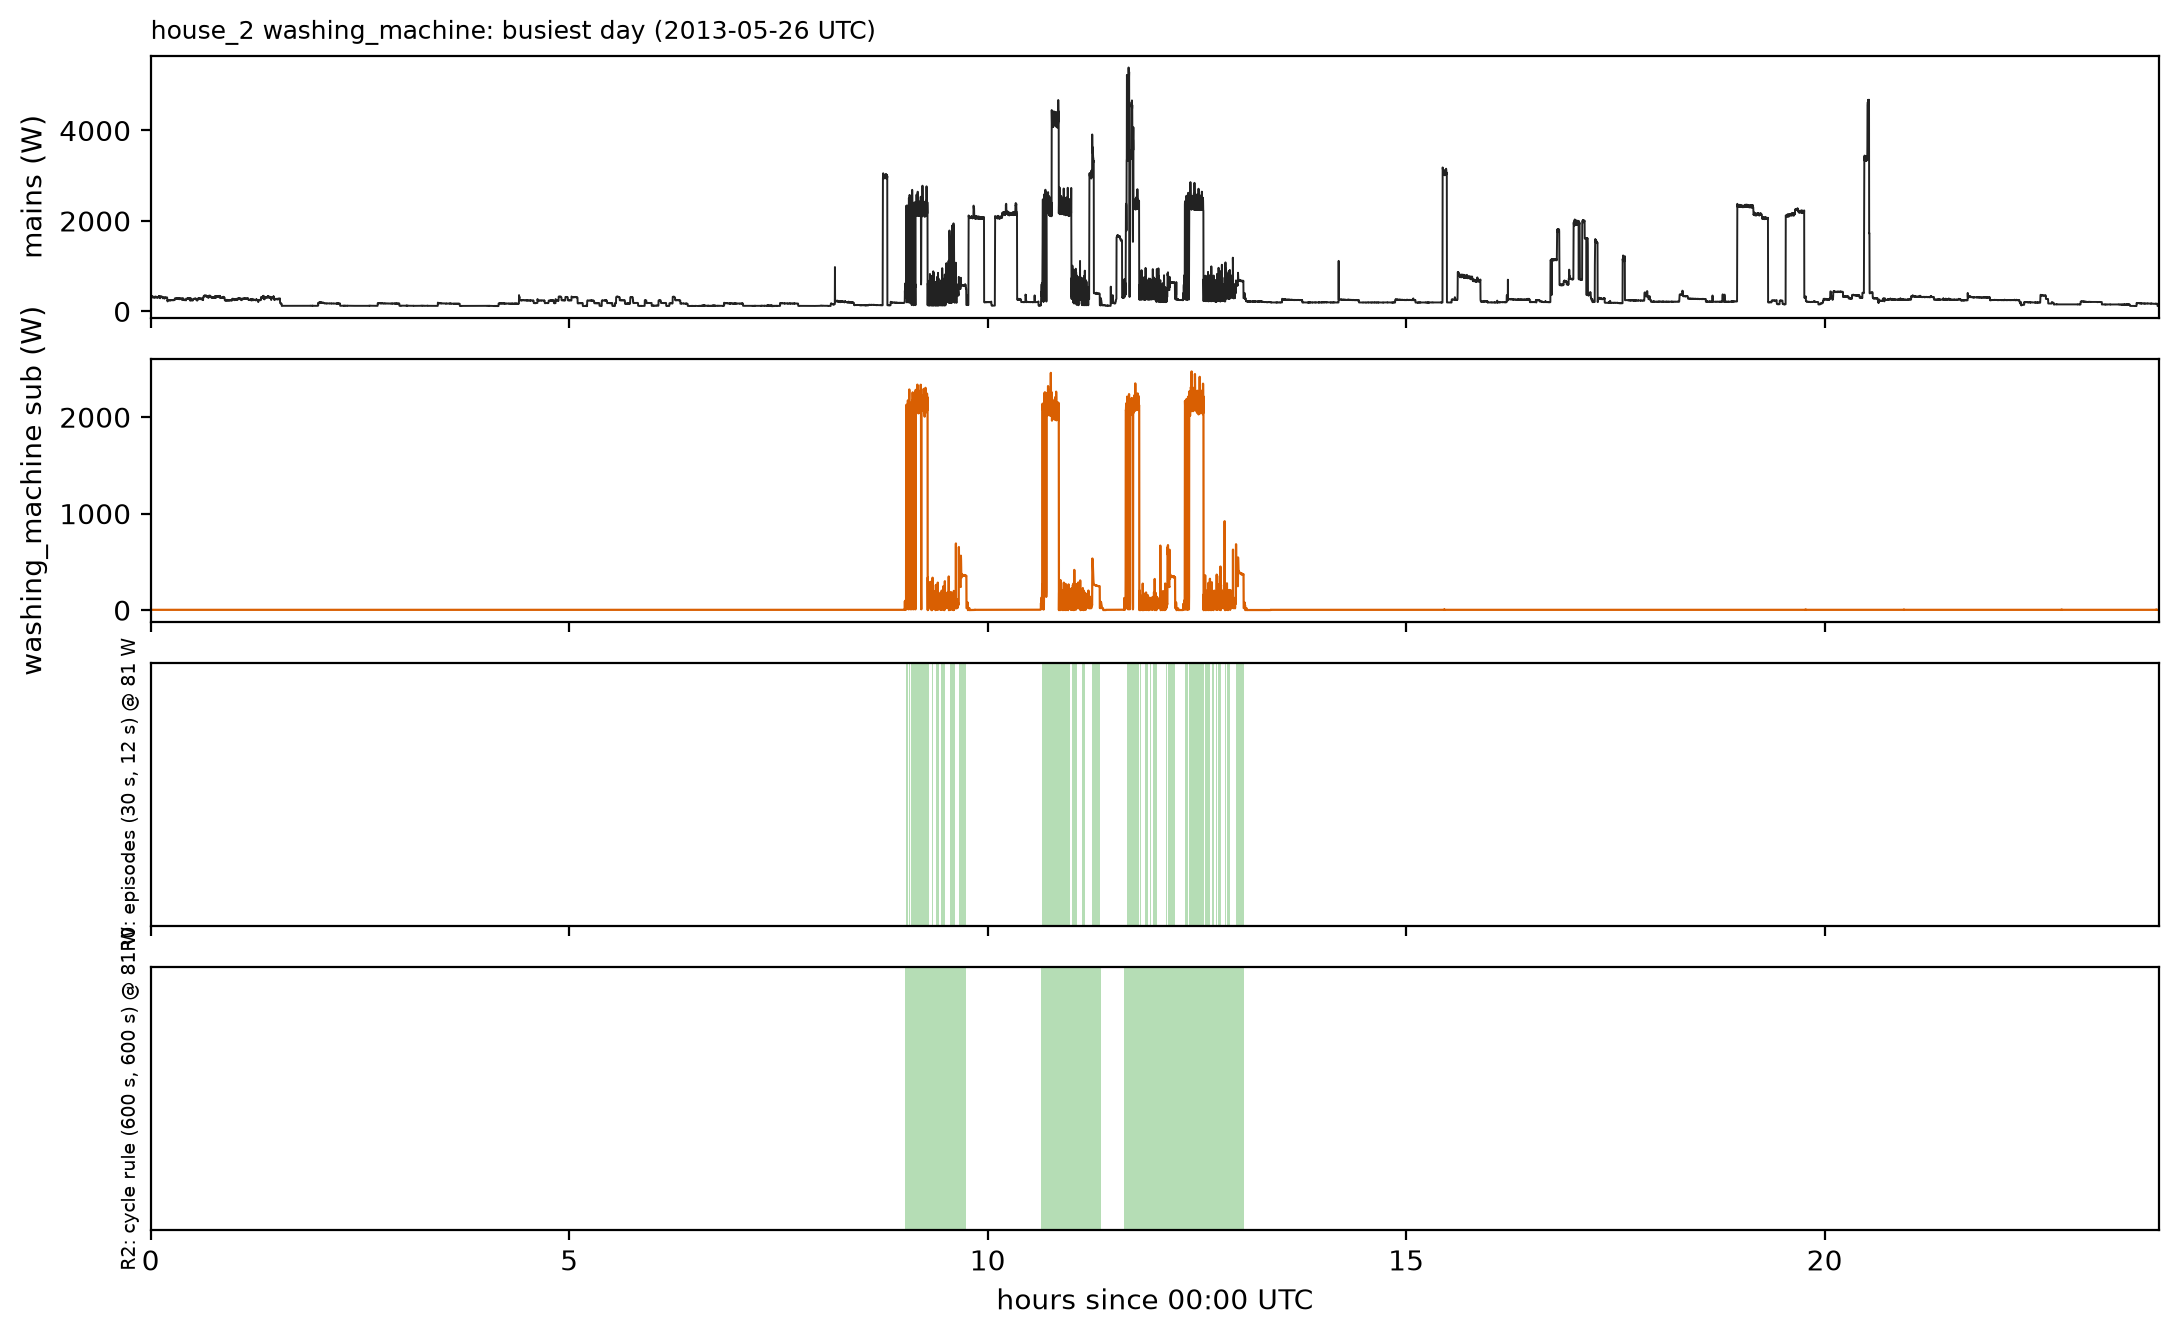

In [ ]:
# --- House 2 WM: rule verification on the busiest day (fig) ------------
h2_wm_day = busy_day("house_2", "washing_machine")[0]
fig_h2_wm = overlay_fig(
    "house_2",
    "washing_machine",
    h2_wm_day,
    [
        ("R0: episodes (30 s, 12 s) @ 81 W", 81.0, 30.0, 12.0),
        ("R2: cycle rule (600 s, 600 s) @ 81 W", 81.0, 600.0, 600.0),
    ],
)
fig_h2_wm  # noqa: B018  (render figure as cell output)

House 2's washing machine behaves like house_1's (multi-activation
program, heater + pump + spin blocks over ~40 min - shorter cycles
than house_1's 91 min median, a real household difference, not a rule
artifact). The cycle rule collapses the episode fragments into
coherent wash blocks. The gold threshold of 81 W is sound here:
on-power p50 is 259 W, comfortably above it.

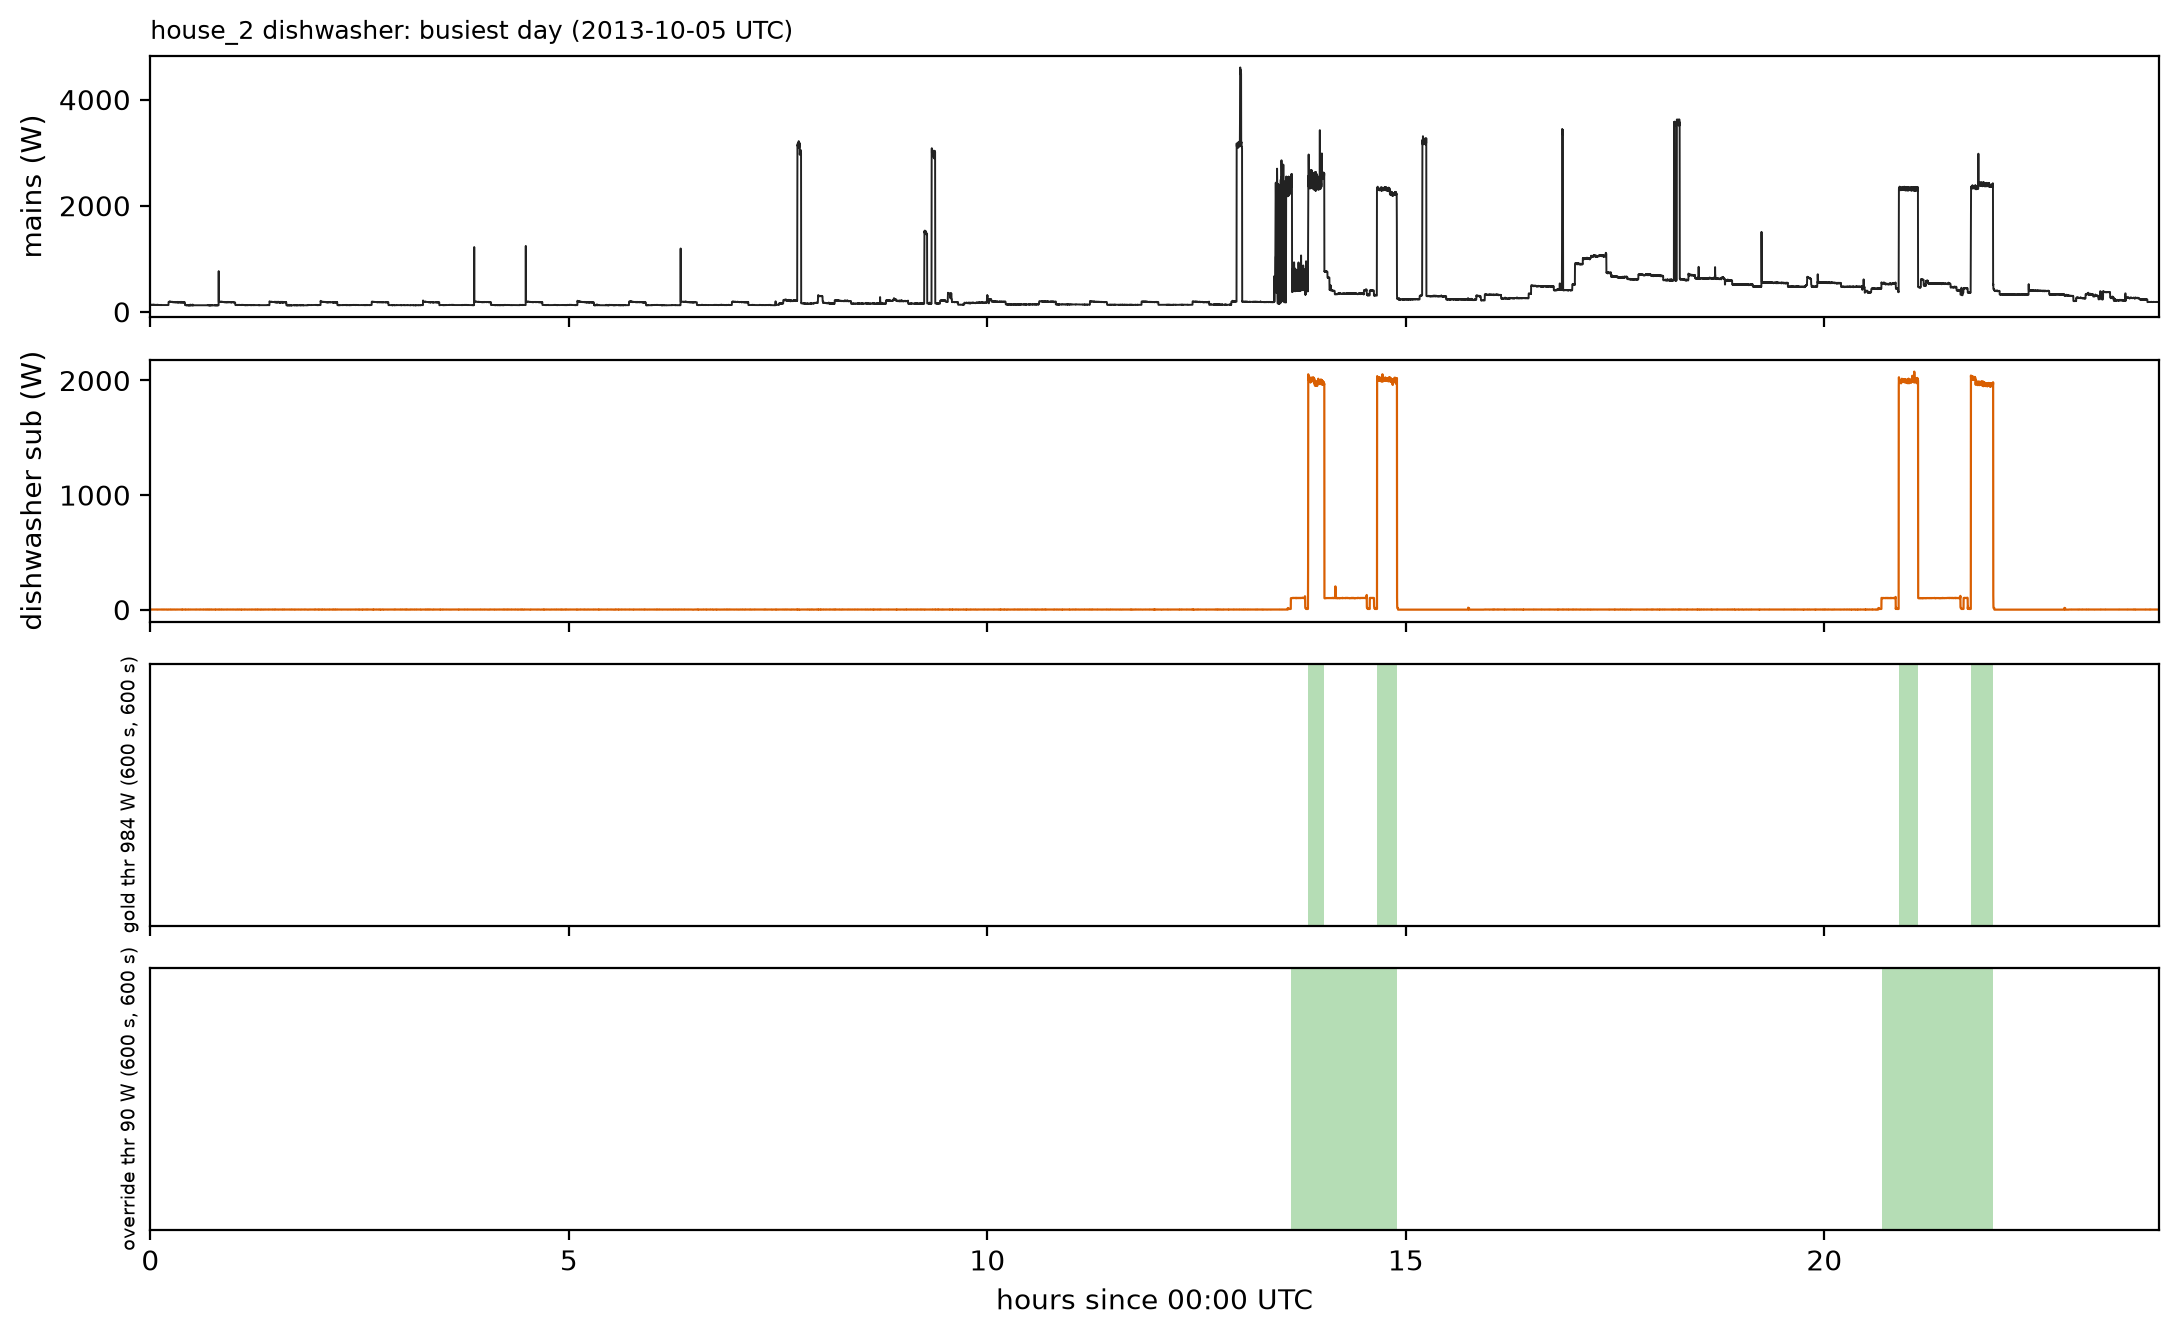

In [ ]:
# --- House 2 DW: threshold override verification (fig) ------------------
# The gold threshold (984 W) is heater-only; the override (90 W) keeps
# the pump/fill phases so one program = one block. Same day, both spans.
h2_dw_day = busy_day("house_2", "dishwasher")[0]
fig_h2_dw = overlay_fig(
    "house_2",
    "dishwasher",
    h2_dw_day,
    [
        ("gold thr 984 W (600 s, 600 s)", 984.0, 600.0, 600.0),
        ("override thr 90 W (600 s, 600 s)", 90.0, 600.0, 600.0),
    ],
)
fig_h2_dw  # noqa: B018  (render figure as cell output)

The picture decides it: at 984 W the dishwasher's own program shatters
into detached heater bursts (each one would look like a separate
"cycle"); at 90 W the program's fill/pump phases connect them into one
block per run. The override is justified by eye, not just by the grid:
**cycle GT for house_2's dishwasher uses 90 W / 600 s / 600 s**.

In [ ]:
# --- House 2 program-cycle stats (independent recomputation) -----------
# Recomputed here from the gold channels - an independent check on the
# builder's device_profile.csv numbers (n / n_cal must match).
h2_cyc = {}
for _dev in ("washing_machine", "dishwasher"):
    _t = thr_used("house_2", _dev)
    _ep = bl.build_episodes(load_chan("house_2", _dev), _t, cfg["cycle_dwell_s"], cfg["cycle_merge_s"], 60.0)
    _cl = _ep[(_ep["dur_s"] >= cfg["cycle_like_s"]) & (_ep["energy_wh"] >= cfg["cycle_like_wh"])]
    _cal = _cl[_cl["t_on_us"] < split_us_of("house_2")]
    h2_cyc[_dev] = {
        "n": int(len(_cl)),
        "n_cal": int(len(_cal)),
        "dur_p50_min": float(_cl["dur_s"].median() / 60.0) if len(_cl) else float("nan"),
        "wh_p50": float(_cl["energy_wh"].median()) if len(_cl) else float("nan"),
        "wh_p90": float(_cl["energy_wh"].quantile(0.9)) if len(_cl) else float("nan"),
    }

In [ ]:
_rows = [
    [
        _dev,
        f"{h2_cyc[_dev]['n']:,}",
        f"{h2_cyc[_dev]['n_cal']:,}",
        f"{h2_cyc[_dev]['dur_p50_min']:.0f}",
        f"{h2_cyc[_dev]['wh_p50']:.0f}",
        f"{h2_cyc[_dev]['wh_p90']:.0f}",
    ]
    for _dev in h2_cyc
]
mo.md(
    "### House 2 program cycles (recomputed here; matches device_profile.csv)\n\n"
    + bl.md_table(
        ["device", "cycles (span)", "in cal span", "p50 dur (min)", "p50 energy (Wh)", "p90 energy (Wh)"],
        _rows,
    )
    + "\n\nEnough candidates in the calibration span on both devices "
    "(the sheet below shows the top 30 by energy)."
)

### House 2 program cycles (recomputed here; matches device_profile.csv)

| device | cycles (span) | in cal span | p50 dur (min) | p50 energy (Wh) | p90 energy (Wh) |
|---|---|---|---|---|---|
| washing_machine | 53 | 36 | 40 | 404 | 623 |
| dishwasher | 106 | 66 | 47 | 1112 | 1222 |

Enough candidates in the calibration span on both devices (the sheet below shows the top 30 by energy).

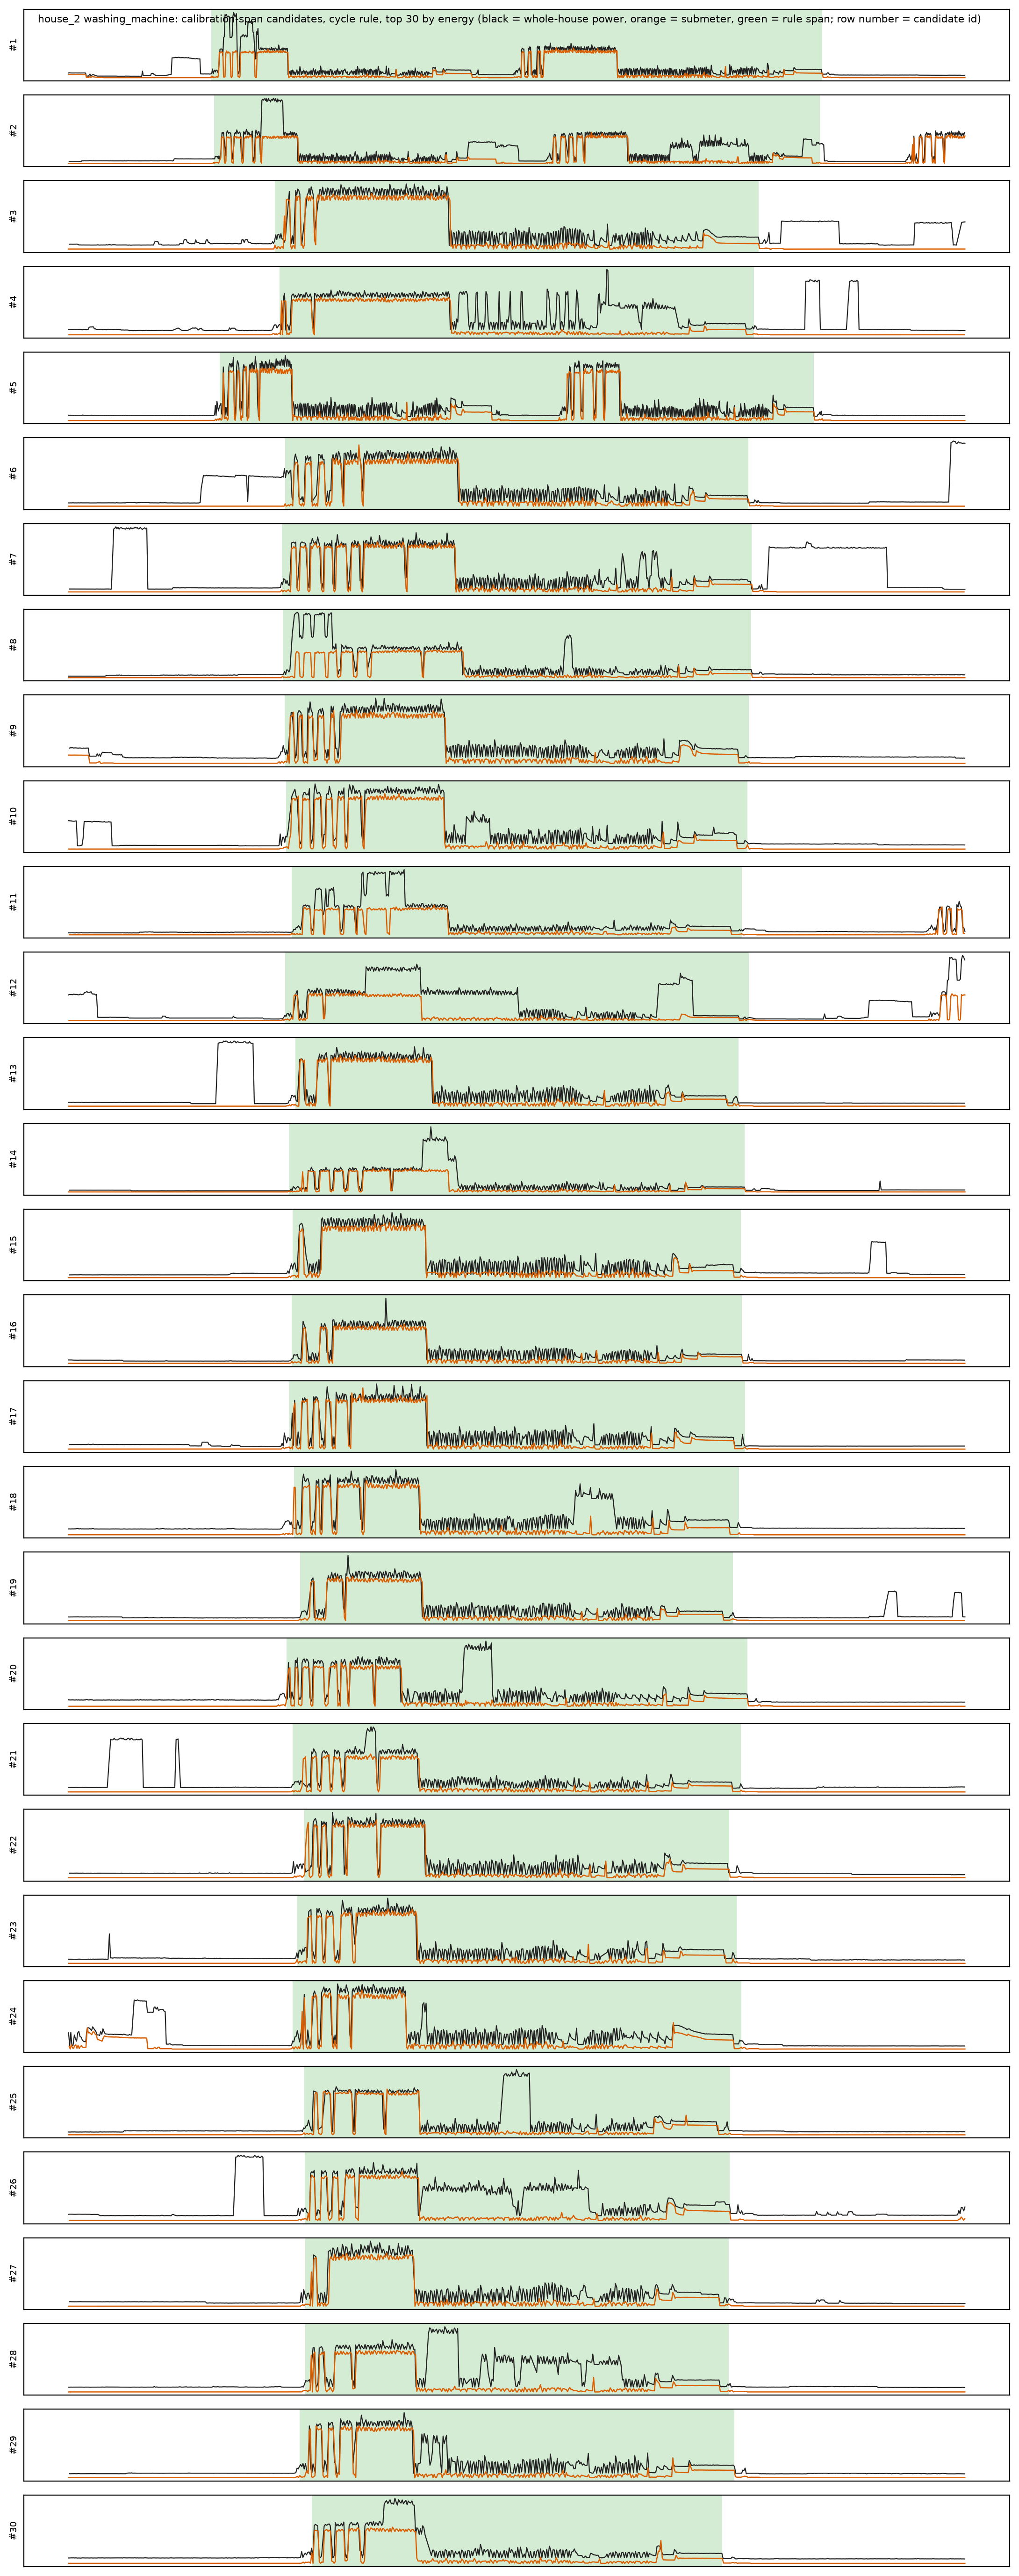

In [ ]:
# --- House 2 WM review sheet (fig) --------------------------------------
fig_h2_wm_sheet, h2_wm_sheet_info = sheet_fig("house_2", "washing_machine")
fig_h2_wm_sheet  # noqa: B018  (render figure as cell output)

In [ ]:
_rows = [
    [str(r["row"]), str(pd.to_datetime(r["t_on_us"], unit="us"))[:16], f"{r['dur_min']:.0f}", f"{r['wh']:.0f}"]
    for r in h2_wm_sheet_info
]
mo.md(
    "### House 2 washing machine: review sheet\n\n"
    + bl.md_table(["row", "cycle start (UTC)", "dur (min)", "energy (Wh)"], _rows)
    + "\n\nEach strip: **black = whole-house power** (what deployment "
    "sees), orange = WM submeter, green = rule span, 20 min of context "
    "either side. KEEP when the span covers exactly one coherent wash "
    "and the wash is recognizable inside the house context; REJECT when "
    "it glues two washes, cuts a soak pause, or drowns in simultaneous "
    "load."
)

### House 2 washing machine: review sheet

| row | cycle start (UTC) | dur (min) | energy (Wh) |
|---|---|---|---|
| 1 | 2013-05-26 11:37 | 86 | 853 |
| 2 | 2013-06-29 10:12 | 83 | 788 |
| 3 | 2013-07-06 13:59 | 47 | 615 |
| 4 | 2013-08-04 11:01 | 45 | 603 |
| 5 | 2013-07-19 09:33 | 78 | 596 |
| 6 | 2013-06-08 10:47 | 43 | 554 |
| 7 | 2013-05-26 09:00 | 44 | 545 |
| 8 | 2013-06-16 10:56 | 44 | 523 |
| 9 | 2013-06-02 11:17 | 43 | 519 |
| 10 | 2013-06-09 12:22 | 42 | 491 |
| 11 | 2013-06-02 10:20 | 40 | 478 |
| 12 | 2013-05-26 10:38 | 43 | 448 |
| 13 | 2013-06-15 07:52 | 39 | 448 |
| 14 | 2013-06-23 08:21 | 41 | 444 |
| 15 | 2013-06-30 11:48 | 40 | 442 |
| 16 | 2013-06-22 09:50 | 40 | 423 |
| 17 | 2013-07-13 09:58 | 41 | 419 |
| 18 | 2013-07-24 12:05 | 39 | 387 |
| 19 | 2013-07-06 11:33 | 37 | 379 |
| 20 | 2013-08-01 11:53 | 42 | 376 |
| 21 | 2013-08-03 08:06 | 40 | 367 |
| 22 | 2013-07-13 11:28 | 36 | 362 |
| 23 | 2013-07-06 09:50 | 38 | 357 |
| 24 | 2013-06-29 11:47 | 40 | 353 |
| 25 | 2013-06-12 08:58 | 36 | 344 |
| 26 | 2013-07-27 11:56 | 36 | 343 |
| 27 | 2013-06-23 09:40 | 36 | 339 |
| 28 | 2013-07-28 12:38 | 36 | 331 |
| 29 | 2013-07-27 08:42 | 38 | 331 |
| 30 | 2013-08-01 10:19 | 34 | 311 |

Each strip: **black = whole-house power** (what deployment sees), orange = WM submeter, green = rule span, 20 min of context either side. KEEP when the span covers exactly one coherent wash and the wash is recognizable inside the house context; REJECT when it glues two washes, cuts a soak pause, or drowns in simultaneous load.

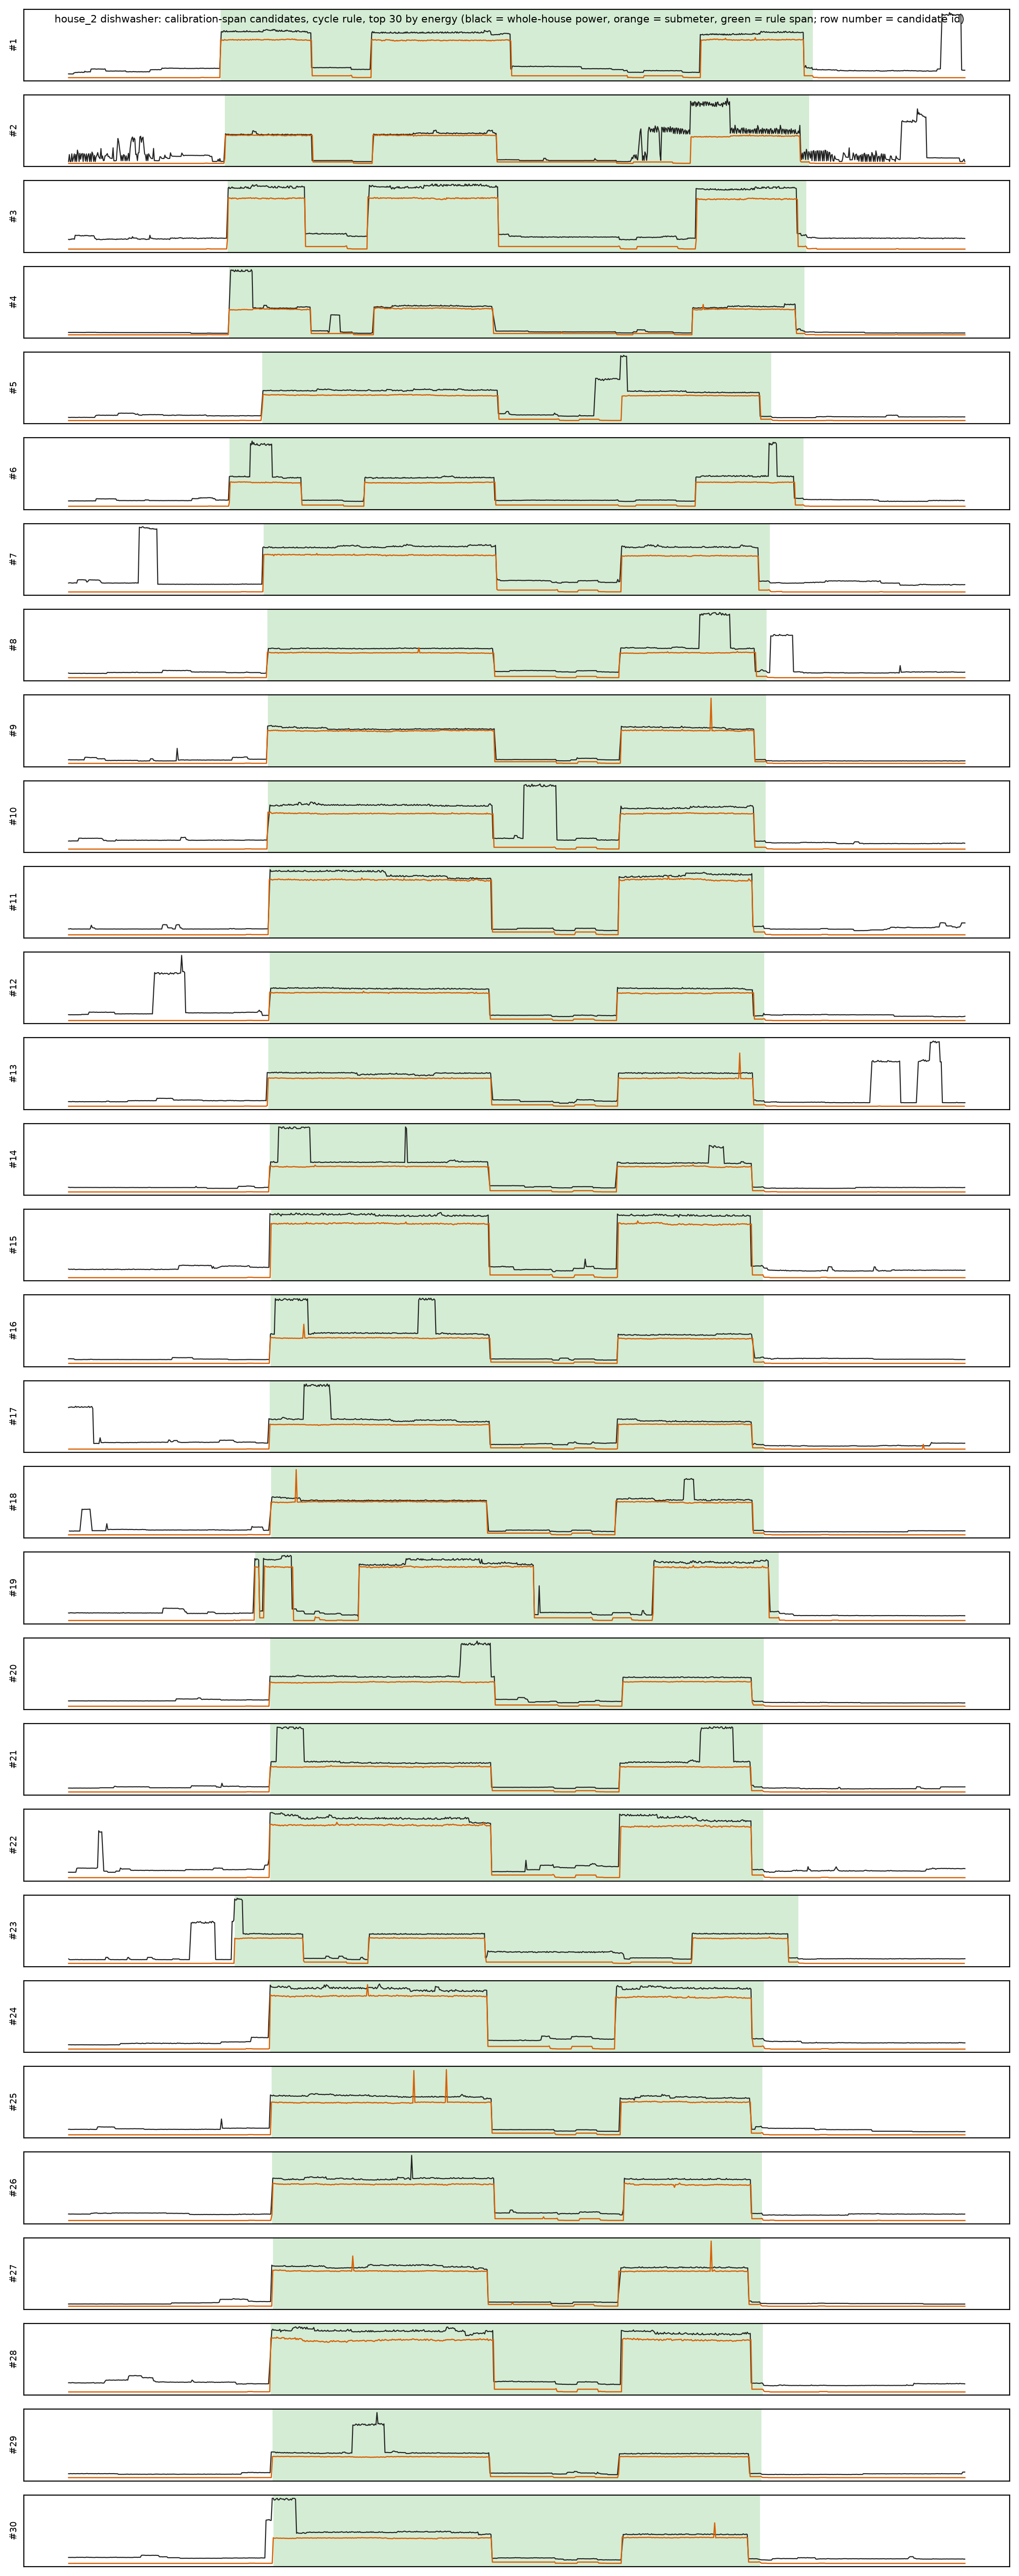

In [ ]:
# --- House 2 DW review sheet (fig) --------------------------------------
fig_h2_dw_sheet, h2_dw_sheet_info = sheet_fig("house_2", "dishwasher")
fig_h2_dw_sheet  # noqa: B018  (render figure as cell output)

In [ ]:
_rows = [
    [str(r["row"]), str(pd.to_datetime(r["t_on_us"], unit="us"))[:16], f"{r['dur_min']:.0f}", f"{r['wh']:.0f}"]
    for r in h2_dw_sheet_info
]
mo.md(
    "### House 2 dishwasher: review sheet\n\n"
    + bl.md_table(["row", "cycle start (UTC)", "dur (min)", "energy (Wh)"], _rows)
    + "\n\nSame reading rules as the WM sheet; at the 90 W override the "
    "green span should cover one full program (fill, heater blocks, "
    "drain)."
)

### House 2 dishwasher: review sheet

| row | cycle start (UTC) | dur (min) | energy (Wh) |
|---|---|---|---|
| 1 | 2013-07-03 18:27 | 78 | 1511 |
| 2 | 2013-05-26 09:46 | 75 | 1411 |
| 3 | 2013-07-28 19:09 | 73 | 1327 |
| 4 | 2013-06-22 08:16 | 71 | 1308 |
| 5 | 2013-05-25 19:03 | 52 | 1284 |
| 6 | 2013-07-27 18:13 | 71 | 1272 |
| 7 | 2013-05-22 19:26 | 52 | 1263 |
| 8 | 2013-05-21 19:38 | 50 | 1226 |
| 9 | 2013-05-31 17:40 | 50 | 1217 |
| 10 | 2013-05-30 19:06 | 50 | 1216 |
| 11 | 2013-05-26 18:57 | 49 | 1205 |
| 12 | 2013-05-28 18:44 | 49 | 1204 |
| 13 | 2013-06-01 18:30 | 50 | 1199 |
| 14 | 2013-05-27 18:47 | 49 | 1192 |
| 15 | 2013-06-02 18:44 | 49 | 1192 |
| 16 | 2013-06-09 17:41 | 49 | 1188 |
| 17 | 2013-05-23 20:52 | 49 | 1187 |
| 18 | 2013-05-29 18:57 | 49 | 1186 |
| 19 | 2013-06-29 18:43 | 56 | 1183 |
| 20 | 2013-06-13 19:11 | 49 | 1179 |
| 21 | 2013-06-10 19:56 | 49 | 1177 |
| 22 | 2013-06-25 18:38 | 49 | 1177 |
| 23 | 2013-07-14 13:12 | 68 | 1175 |
| 24 | 2013-06-03 18:22 | 49 | 1172 |
| 25 | 2013-06-07 19:01 | 48 | 1157 |
| 26 | 2013-07-04 18:32 | 48 | 1156 |
| 27 | 2013-06-12 21:57 | 48 | 1156 |
| 28 | 2013-06-26 19:00 | 49 | 1155 |
| 29 | 2013-06-08 18:59 | 48 | 1153 |
| 30 | 2013-06-24 19:27 | 47 | 1152 |

Same reading rules as the WM sheet; at the 90 W override the green span should cover one full program (fill, heater blocks, drain).

In [ ]:
# --- House 2 curated marks from the store (computation) -----------------
h2_runs = runs_of("house_2")
h2_cur_wm = curated("house_2", "washing_machine")
h2_cur_dw = curated("house_2", "dishwasher")
h2_feat_wm = cycle_features(h2_cur_wm, h2_runs) if h2_cur_wm is not None else None
h2_feat_dw = cycle_features(h2_cur_dw, h2_runs) if h2_cur_dw is not None else None

In [ ]:
# presentation: house 2 curated marks + mark-derived profile features
_parts = []
for _dev, _cur, _feat in (
    ("washing_machine", h2_cur_wm, h2_feat_wm),
    ("dishwasher", h2_cur_dw, h2_feat_dw),
):
    if _cur is None:
        _parts.append(
            f"**{_dev}**: no curated marks in the store yet - the review "
            "sheet above is the pending artifact. Curation appends to "
            "data/gold_annot/ukdale/house_2/manual_cycles.csv (source tag "
            "manual_review_v1) and this section fills on re-export."
        )
    else:
        _rows = [
            [
                str(_i + 1),
                str(pd.to_datetime(_r.t_on_us, unit="us"))[:16],
                f"{_r.dur_s / 60.0:.0f}",
                f"{_feat['dp_peak'].iloc[_i]:.0f}" if _feat is not None and _feat["dp_peak"].notna().iloc[_i] else "-",
            ]
            for _i, _r in enumerate(_cur.itertuples())
        ]
        _dp_ok = int(_feat["dp_peak"].notna().sum()) if _feat is not None else 0
        _parts.append(
            f"**{_dev}**: {len(_cur)} curated marks (source "
            f"{_cur['source'].iloc[0]}), all inside the calibration "
            "span.\n\n"
            + bl.md_table(["#", "t_on (UTC)", "dur (min)", "strongest in-cycle activation dP (W)"], _rows)
            + f"\n\n{_dp_ok} of {len(_cur)} marks have a detectable "
            "aggregate activation inside their span (the rest profile by "
            "duration only - the quiet-fill finding from house_1 holds "
            "here too)."
        )
mo.md("### Curated marks, house 2 (loaded from the store)\n\n" + "\n\n".join(_parts))

### Curated marks, house 2 (loaded from the store)

**washing_machine**: 20 curated marks (source manual_review_v1), all inside the calibration span.

| # | t_on (UTC) | dur (min) | strongest in-cycle activation dP (W) |
|---|---|---|---|
| 1 | 2013-05-26 11:37 | 86 | 4912 |
| 2 | 2013-06-29 10:12 | 83 | 4832 |
| 3 | 2013-07-06 13:59 | 47 | 2335 |
| 4 | 2013-08-04 11:01 | 45 | 3079 |
| 5 | 2013-07-19 09:33 | 78 | 2397 |
| 6 | 2013-06-08 10:47 | 43 | 2157 |
| 7 | 2013-05-26 09:00 | 44 | 2048 |
| 8 | 2013-06-16 10:56 | 44 | 4846 |
| 9 | 2013-06-02 11:17 | 43 | 3301 |
| 10 | 2013-06-09 12:22 | 42 | 2380 |
| 11 | 2013-06-02 10:20 | 40 | 4945 |
| 12 | 2013-05-26 10:38 | 43 | 4009 |
| 13 | 2013-06-15 07:52 | 39 | 2186 |
| 14 | 2013-06-23 08:21 | 41 | 5043 |
| 15 | 2013-06-30 11:48 | 40 | 2421 |
| 16 | 2013-06-22 09:50 | 40 | 2411 |
| 17 | 2013-07-13 09:58 | 41 | 2148 |
| 18 | 2013-07-24 12:05 | 39 | 2301 |
| 19 | 2013-07-06 11:33 | 37 | 2415 |
| 20 | 2013-08-01 11:53 | 42 | 2945 |

20 of 20 marks have a detectable aggregate activation inside their span (the rest profile by duration only - the quiet-fill finding from house_1 holds here too).

**dishwasher**: 20 curated marks (source manual_review_v1), all inside the calibration span.

| # | t_on (UTC) | dur (min) | strongest in-cycle activation dP (W) |
|---|---|---|---|
| 1 | 2013-07-03 18:27 | 78 | 3102 |
| 2 | 2013-05-26 09:46 | 75 | 4009 |
| 3 | 2013-07-28 19:09 | 73 | 3084 |
| 4 | 2013-06-22 08:16 | 71 | 4846 |
| 5 | 2013-05-25 19:03 | 52 | 4659 |
| 6 | 2013-07-27 18:13 | 71 | 4835 |
| 7 | 2013-05-22 19:26 | 52 | 2121 |
| 8 | 2013-05-21 19:38 | 50 | 4755 |
| 9 | 2013-05-31 17:40 | 50 | 2012 |
| 10 | 2013-05-30 19:06 | 50 | 1920 |
| 11 | 2013-05-26 18:57 | 49 | 2128 |
| 12 | 2013-05-28 18:44 | 49 | 2007 |
| 13 | 2013-06-01 18:30 | 50 | 4200 |
| 14 | 2013-05-27 18:47 | 49 | 4752 |
| 15 | 2013-06-02 18:44 | 49 | 2040 |
| 16 | 2013-06-09 17:41 | 49 | 4800 |
| 17 | 2013-05-23 20:52 | 49 | 4699 |
| 18 | 2013-05-29 18:57 | 49 | 3185 |
| 19 | 2013-06-29 18:43 | 56 | 2154 |
| 20 | 2013-06-13 19:11 | 49 | 3149 |

20 of 20 marks have a detectable aggregate activation inside their span (the rest profile by duration only - the quiet-fill finding from house_1 holds here too).

## House 5 - washer_dryer, a broken threshold, and a dead channel

House 5 (2014-06-29 to 2014-11-13, 137 days) has the full canonical
set, but the grid probe failed two channels outright: the washing
machine's gold threshold of **7.5 W** turns standby noise into nine
day-scale mega-episodes, and the microwave channel reads a **constant
~50 W around the clock** (p99 = 51 W) - there is no appliance signal
in it at all. The WM gets a 50 W override; the MW is excluded.

In [ ]:
# --- House 5 data health (computation) ----------------------------------
def _modal_dt_s(ts_us):
    d = np.diff(ts_us) / 1e6
    d = d[(d > 0) & (d < 60)]
    if d.size == 0:
        return float("nan")
    vals, counts = np.unique(np.round(d, 1), return_counts=True)
    return float(vals[np.argmax(counts)])

h5_health = []
for _name in ("mains", "washing_machine", "dishwasher", "kettle", "microwave", "fridge"):
    _df = load_chan("house_5", _name)
    _ts = _df["ts_us"].to_numpy(np.int64)
    _dt = _modal_dt_s(_ts)
    h5_health.append(
        {
            "channel": _name,
            "rows": int(_ts.size),
            "modal_dt_s": _dt,
            "fill": _ts.size / max((_ts[-1] - _ts[0]) / (_dt * 1e6), 1.0),
        }
    )

In [ ]:
_rows = [
    [c["channel"], f"{c['rows']:,}", f"{c['modal_dt_s']:.1f}", f"{100 * c['fill']:.0f}%"]
    for c in h5_health
]
mo.md(
    "### House 5 data health (measured)\n\n"
    + bl.md_table(["channel", "rows", "modal dt (s)", "modal-interval fill"], _rows)
    + "\n\n137 days at 6 s. Test span reserved from 2014-10-10 "
    "(splits.csv). Note the microwave channel's fill: it reads "
    "continuously - consistent with the constant-~50 W finding, i.e. a "
    "standby/clock load on that circuit, not a microwave."
)

### House 5 data health (measured)

| channel | rows | modal dt (s) | modal-interval fill |
|---|---|---|---|
| mains | 1,763,101 | 6.0 | 89% |
| washing_machine | 1,859,562 | 6.0 | 94% |
| dishwasher | 1,859,593 | 6.0 | 94% |
| kettle | 985,855 | 6.0 | 98% |
| microwave | 1,859,545 | 6.0 | 94% |
| fridge | 1,842,971 | 6.0 | 93% |

137 days at 6 s. Test span reserved from 2014-10-10 (splits.csv). Note the microwave channel's fill: it reads continuously - consistent with the constant-~50 W finding, i.e. a standby/clock load on that circuit, not a microwave.

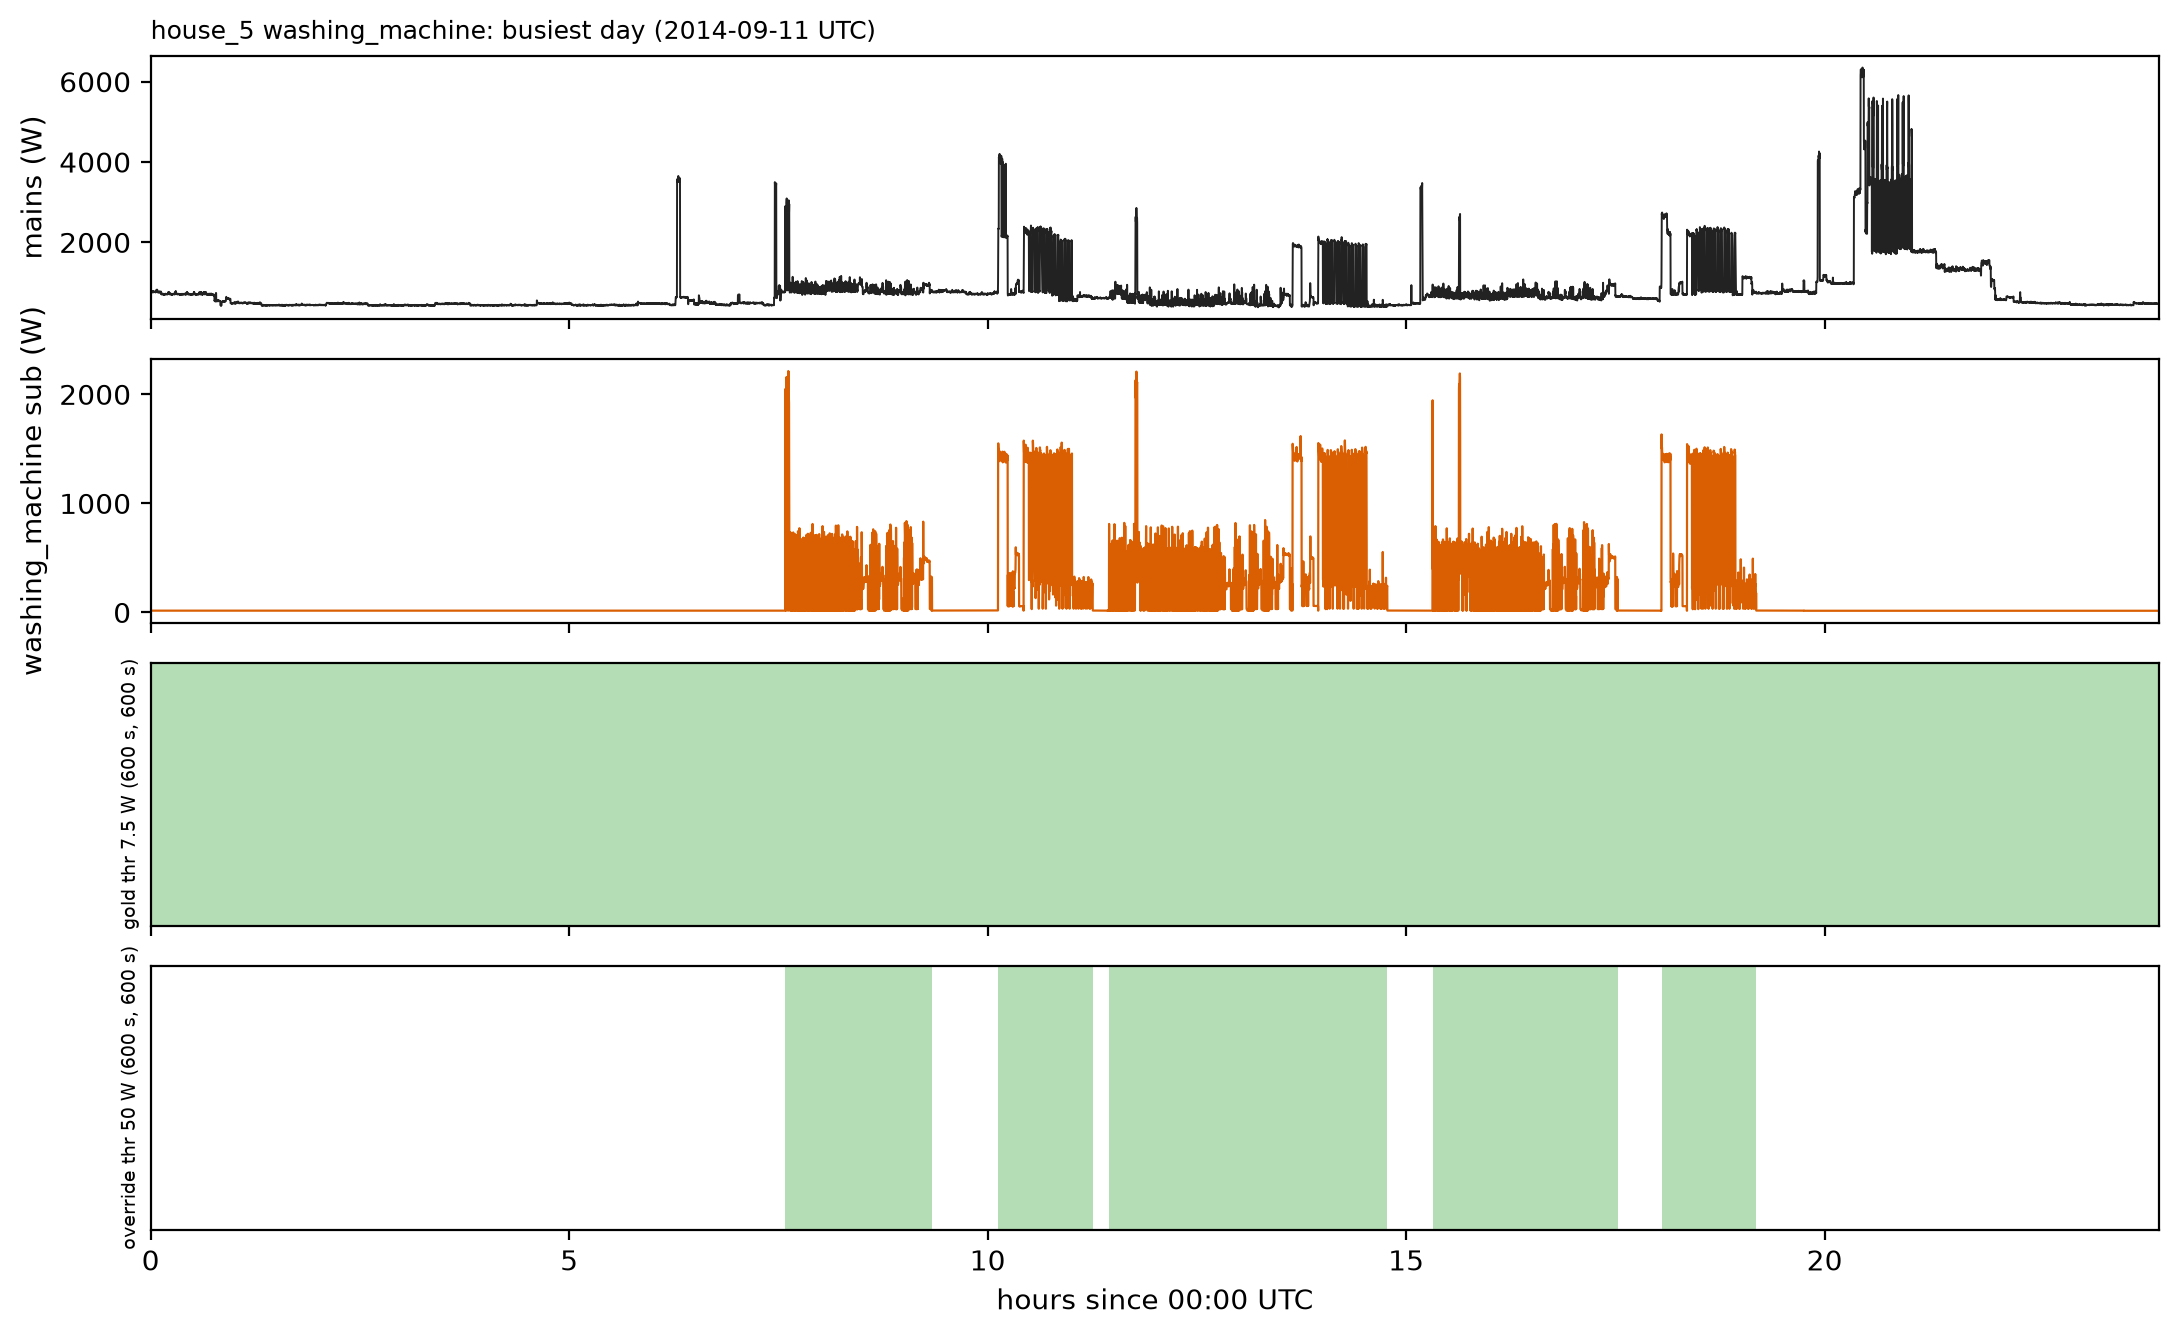

In [ ]:
# --- House 5 WM: override verification (fig) ----------------------------
h5_wm_day = busy_day("house_5", "washing_machine")[0]
fig_h5_wm = overlay_fig(
    "house_5",
    "washing_machine",
    h5_wm_day,
    [
        ("gold thr 7.5 W (600 s, 600 s)", 7.5, 600.0, 600.0),
        ("override thr 50 W (600 s, 600 s)", 50.0, 600.0, 600.0),
    ],
)
fig_h5_wm  # noqa: B018  (render figure as cell output)

At 7.5 W the rule spans the whole day (green washes over everything -
that is the mega-episode failure). At 50 W the spans land on real
washer runs. This is the cleanest demonstration in the notebook of why
a threshold must be verified before any cycle count is quoted: the
gold value would have produced "9 washing cycles, each 4 days long".
**Cycle GT for house_5's washing machine uses 50 W / 600 s / 600 s**;
the washer_dryer label means some runs include a heated dry phase -
the sheets below separate the two by eye.

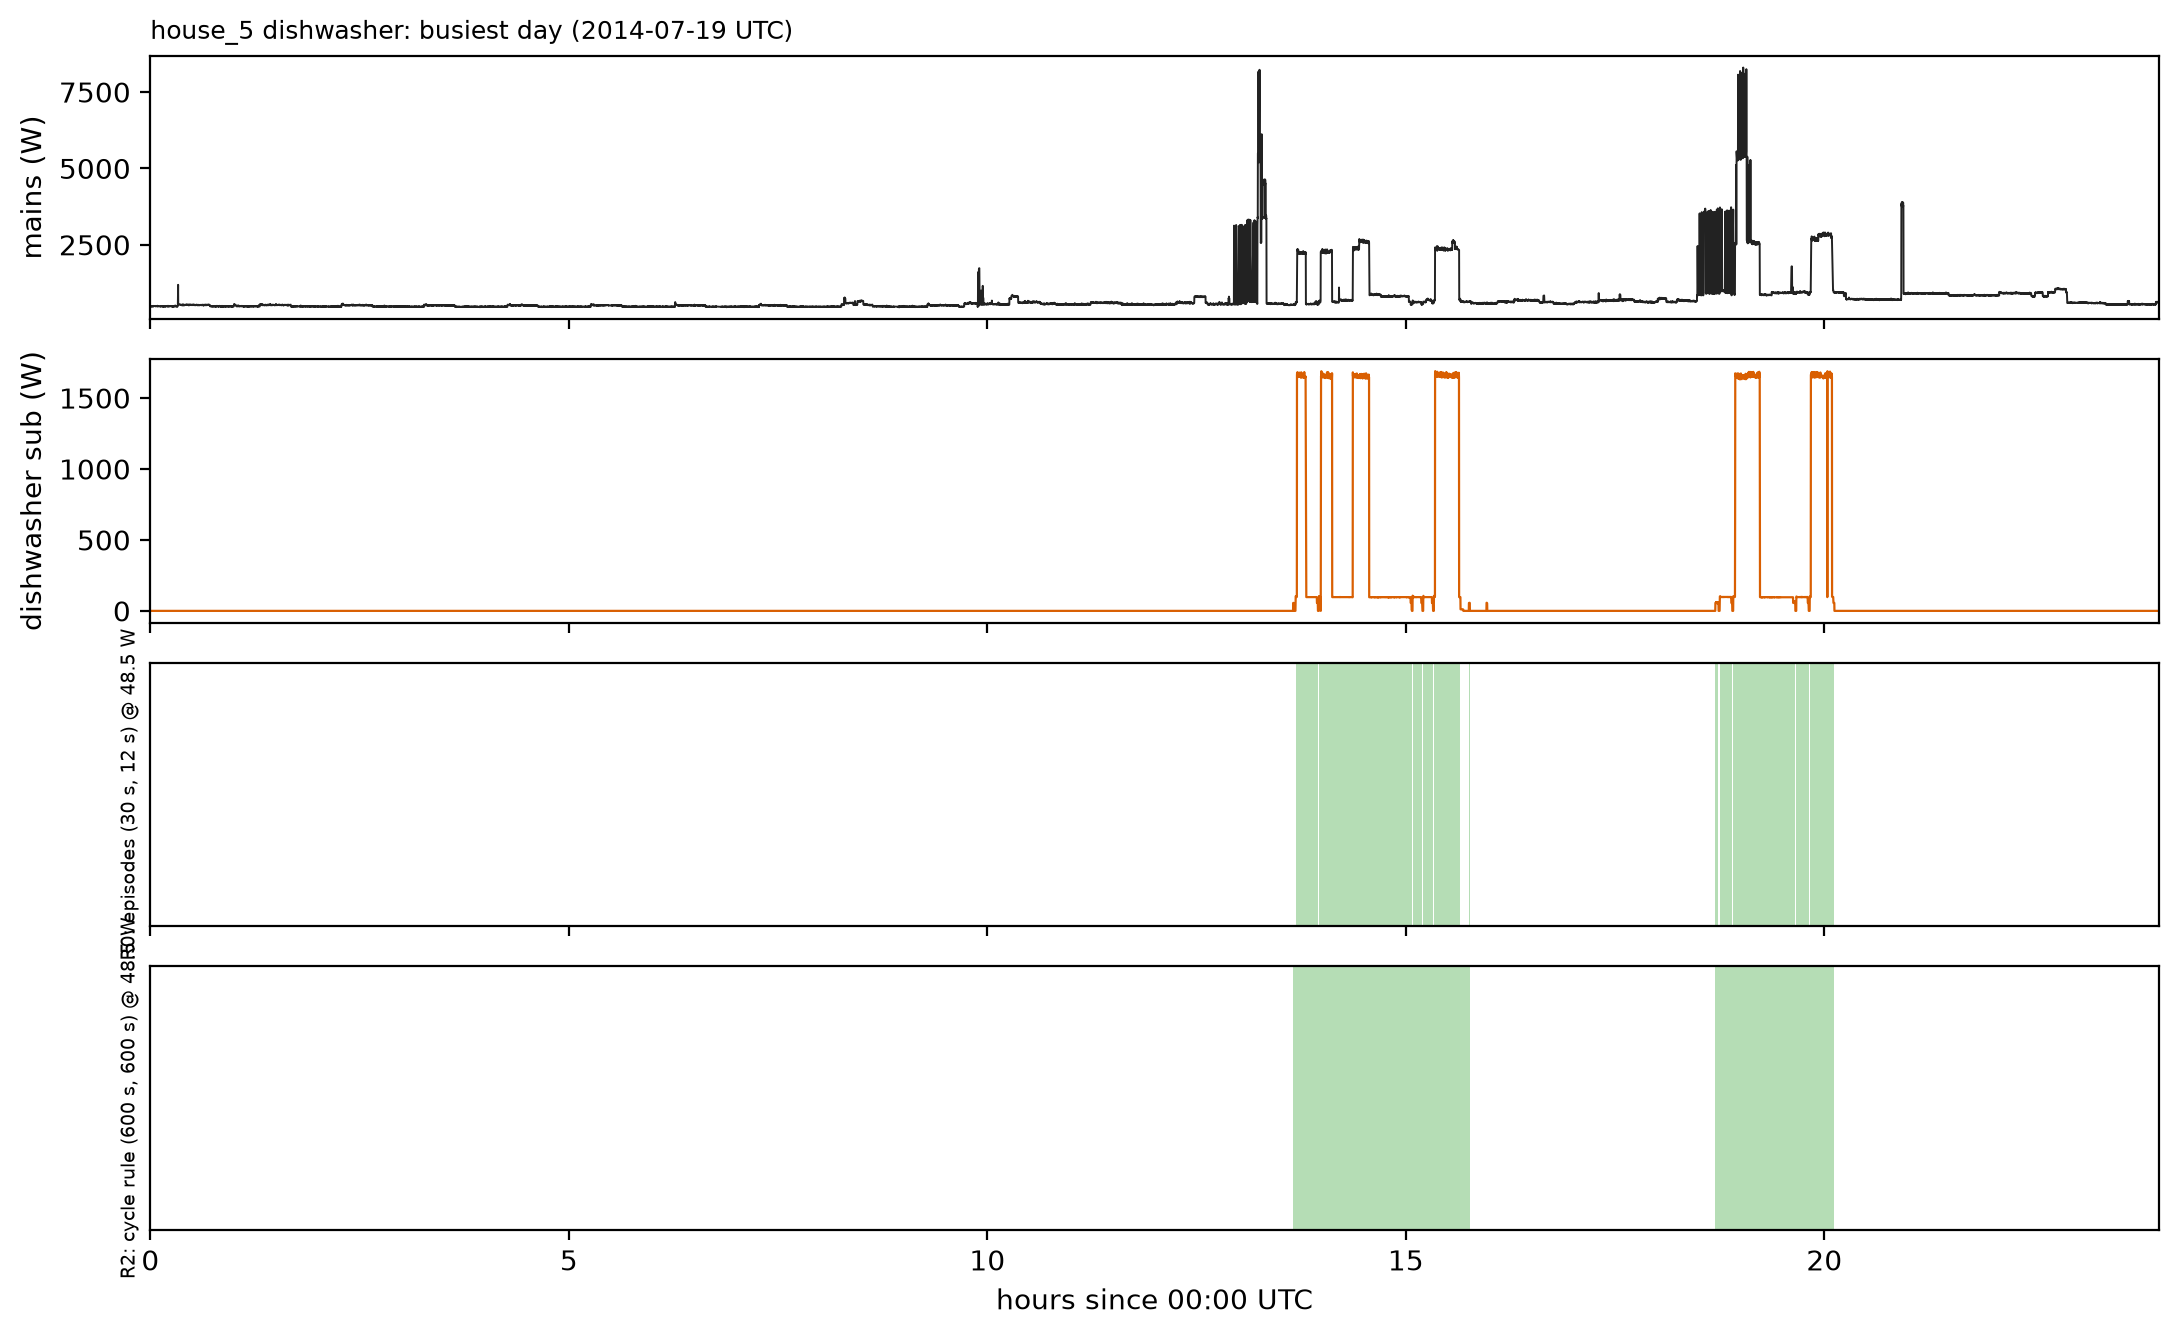

In [ ]:
# --- House 5 DW: rule verification (fig) --------------------------------
h5_dw_day = busy_day("house_5", "dishwasher")[0]
fig_h5_dw = overlay_fig(
    "house_5",
    "dishwasher",
    h5_dw_day,
    [
        ("R0: episodes (30 s, 12 s) @ 48.5 W", 48.5, 30.0, 12.0),
        ("R2: cycle rule (600 s, 600 s) @ 48.5 W", 48.5, 600.0, 600.0),
    ],
)
fig_h5_dw  # noqa: B018  (render figure as cell output)

House 5's dishwasher threshold (48.5 W) is sane - on-power p50 97 W -
and the cycle rule again collapses episode fragments into program-scale
blocks (~90 min p50, 1104 Wh p50: a hot intensive program).

In [ ]:
# --- House 5 program-cycle stats (independent recomputation) ------------
h5_cyc = {}
for _dev in ("washing_machine", "dishwasher"):
    _t = thr_used("house_5", _dev)
    _ep = bl.build_episodes(load_chan("house_5", _dev), _t, cfg["cycle_dwell_s"], cfg["cycle_merge_s"], 60.0)
    _cl = _ep[(_ep["dur_s"] >= cfg["cycle_like_s"]) & (_ep["energy_wh"] >= cfg["cycle_like_wh"])]
    _cal = _cl[_cl["t_on_us"] < split_us_of("house_5")]
    h5_cyc[_dev] = {
        "n": int(len(_cl)),
        "n_cal": int(len(_cal)),
        "dur_p50_min": float(_cl["dur_s"].median() / 60.0) if len(_cl) else float("nan"),
        "wh_p50": float(_cl["energy_wh"].median()) if len(_cl) else float("nan"),
        "wh_p90": float(_cl["energy_wh"].quantile(0.9)) if len(_cl) else float("nan"),
    }

In [ ]:
_rows = [
    [
        _dev,
        f"{h5_cyc[_dev]['n']:,}",
        f"{h5_cyc[_dev]['n_cal']:,}",
        f"{h5_cyc[_dev]['dur_p50_min']:.0f}",
        f"{h5_cyc[_dev]['wh_p50']:.0f}",
        f"{h5_cyc[_dev]['wh_p90']:.0f}",
    ]
    for _dev in h5_cyc
]
mo.md(
    "### House 5 program cycles (recomputed here; matches device_profile.csv)\n\n"
    + bl.md_table(
        ["device", "cycles (span)", "in cal span", "p50 dur (min)", "p50 energy (Wh)", "p90 energy (Wh)"],
        _rows,
    )
 + "\n\n85 WM and 38 DW calibration-span candidates - enough for a "
    "20-mark curation on both devices."
)

### House 5 program cycles (recomputed here; matches device_profile.csv)

| device | cycles (span) | in cal span | p50 dur (min) | p50 energy (Wh) | p90 energy (Wh) |
|---|---|---|---|---|---|
| washing_machine | 110 | 85 | 75 | 792 | 1425 |
| dishwasher | 47 | 38 | 90 | 1104 | 1363 |

85 WM and 38 DW calibration-span candidates - enough for a 20-mark curation on both devices.

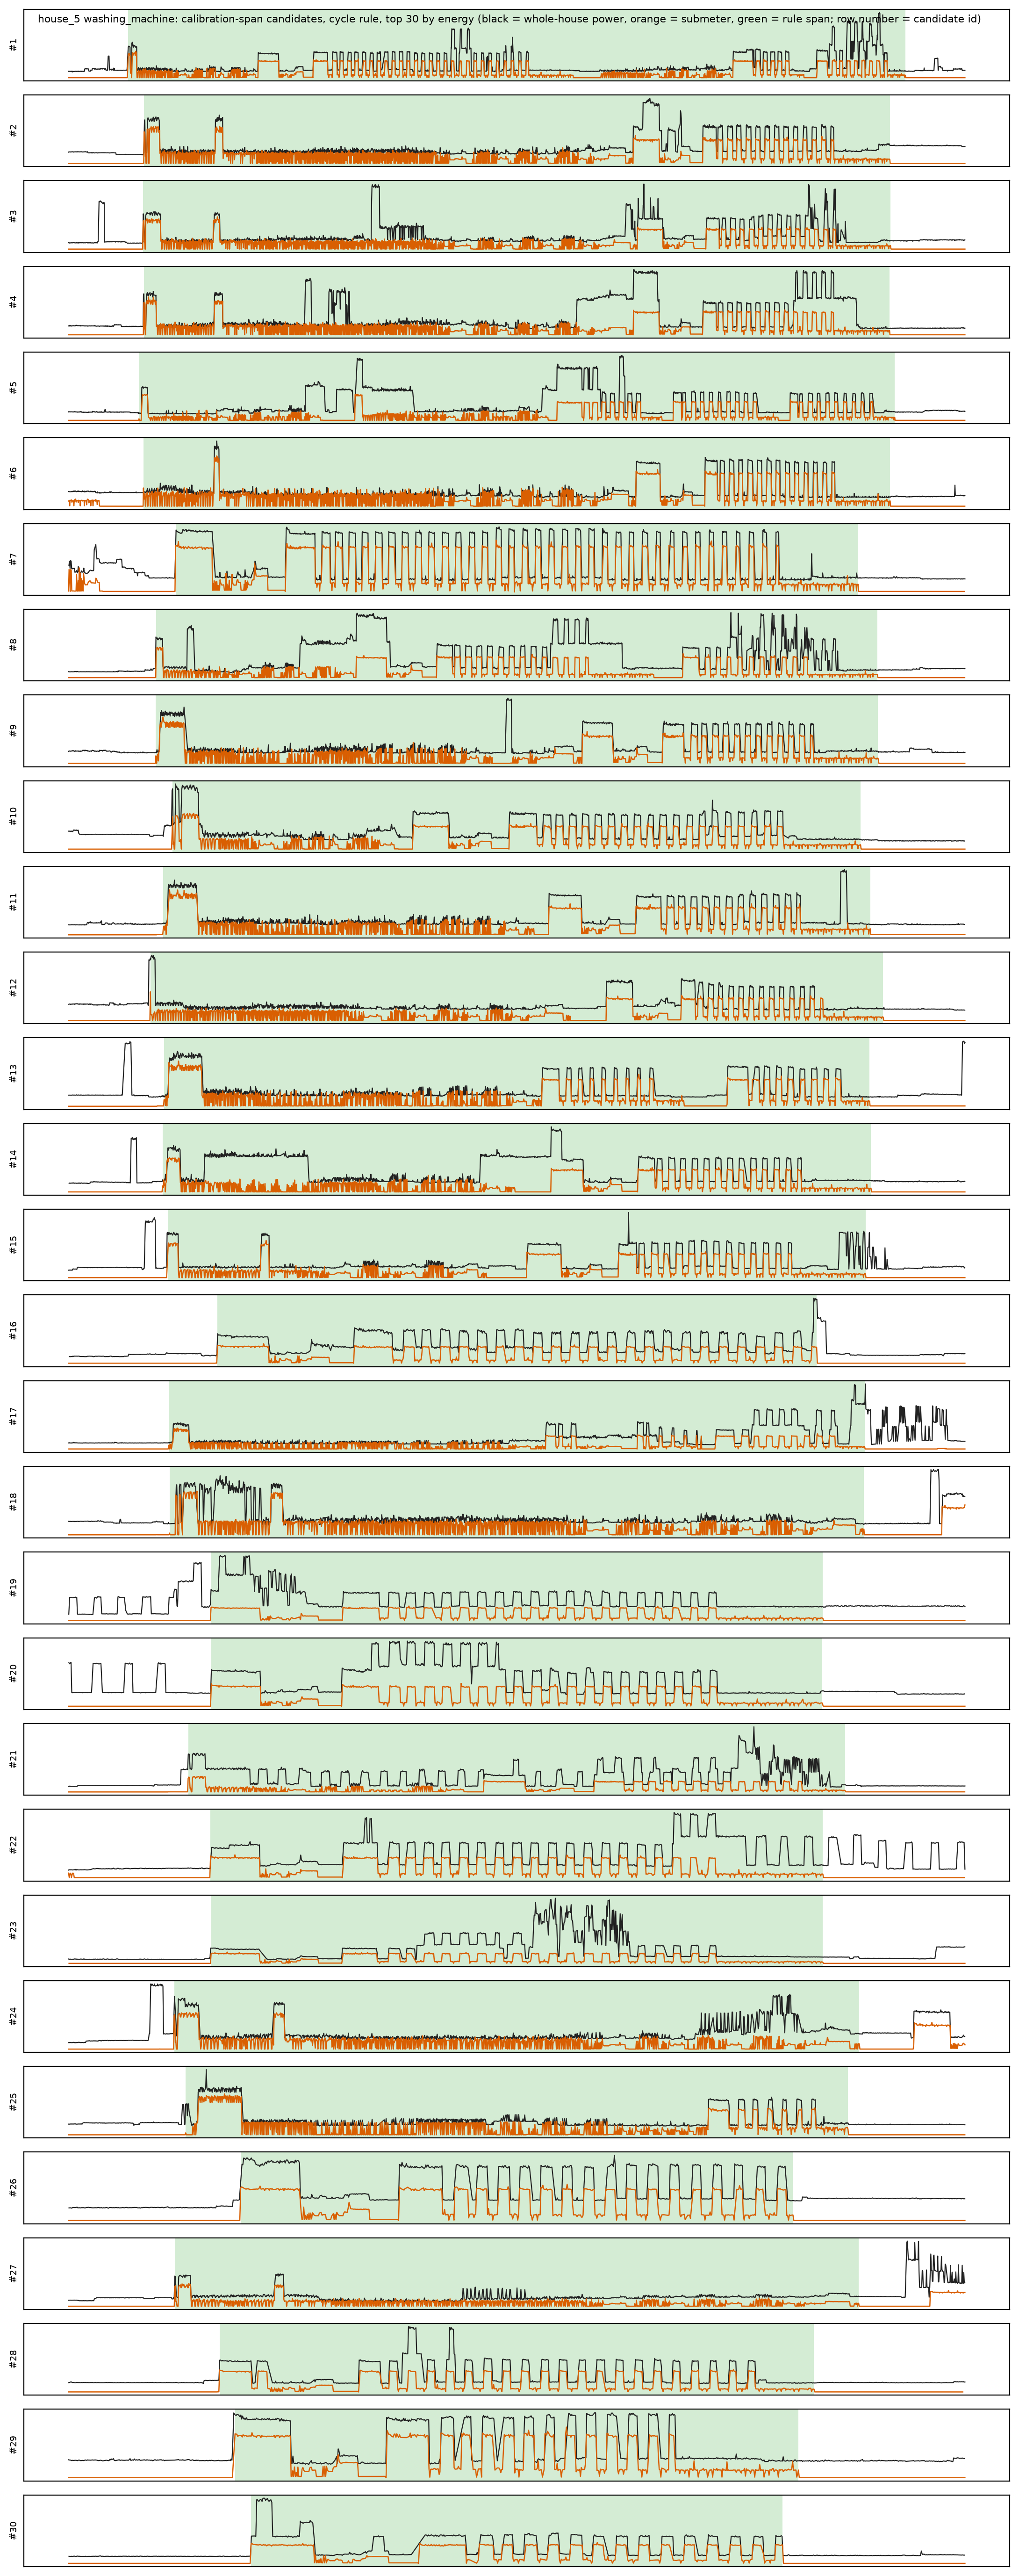

In [ ]:
# --- House 5 WM review sheet (fig) --------------------------------------
fig_h5_wm_sheet, h5_wm_sheet_info = sheet_fig("house_5", "washing_machine")
fig_h5_wm_sheet  # noqa: B018  (render figure as cell output)

In [ ]:
_rows = [
    [str(r["row"]), str(pd.to_datetime(r["t_on_us"], unit="us"))[:16], f"{r['dur_min']:.0f}", f"{r['wh']:.0f}"]
    for r in h5_wm_sheet_info
]
mo.md(
    "### House 5 washing machine: review sheet\n\n"
    + bl.md_table(["row", "cycle start (UTC)", "dur (min)", "energy (Wh)"], _rows)
    + "\n\nReading rules as before; washer_dryer caveat applies - a "
    "candidate is KEEP when the wash phase is coherent and "
    "aggregate-recognizable, with any dry phase either cleanly inside "
    "the span or absent."
)

### House 5 washing machine: review sheet

| row | cycle start (UTC) | dur (min) | energy (Wh) |
|---|---|---|---|
| 1 | 2014-07-05 08:26 | 260 | 2317 |
| 2 | 2014-09-10 15:48 | 197 | 1793 |
| 3 | 2014-09-26 09:59 | 200 | 1722 |
| 4 | 2014-09-17 12:11 | 198 | 1700 |
| 5 | 2014-07-22 09:30 | 215 | 1614 |
| 6 | 2014-09-11 11:27 | 199 | 1520 |
| 7 | 2014-09-18 23:03 | 128 | 1477 |
| 8 | 2014-09-19 08:06 | 165 | 1427 |
| 9 | 2014-09-05 12:08 | 166 | 1425 |
| 10 | 2014-07-01 20:49 | 132 | 1420 |
| 11 | 2014-08-14 09:02 | 149 | 1375 |
| 12 | 2014-09-10 19:39 | 179 | 1375 |
| 13 | 2014-08-13 10:06 | 148 | 1297 |
| 14 | 2014-08-13 12:59 | 150 | 1185 |
| 15 | 2014-10-02 08:40 | 140 | 1181 |
| 16 | 2014-09-14 14:22 | 80 | 1135 |
| 17 | 2014-08-13 15:59 | 138 | 1095 |
| 18 | 2014-09-16 12:32 | 137 | 1066 |
| 19 | 2014-08-31 19:00 | 86 | 1059 |
| 20 | 2014-07-08 19:38 | 86 | 1054 |
| 21 | 2014-09-22 17:46 | 109 | 1044 |
| 22 | 2014-08-24 16:36 | 86 | 1039 |
| 23 | 2014-07-13 18:31 | 86 | 1024 |
| 24 | 2014-10-06 09:56 | 129 | 968 |
| 25 | 2014-07-09 09:53 | 113 | 967 |
| 26 | 2014-08-06 19:14 | 64 | 880 |
| 27 | 2014-10-06 16:08 | 129 | 880 |
| 28 | 2014-06-29 17:37 | 79 | 865 |
| 29 | 2014-07-30 14:50 | 68 | 825 |
| 30 | 2014-07-25 08:49 | 58 | 818 |

Reading rules as before; washer_dryer caveat applies - a candidate is KEEP when the wash phase is coherent and aggregate-recognizable, with any dry phase either cleanly inside the span or absent.

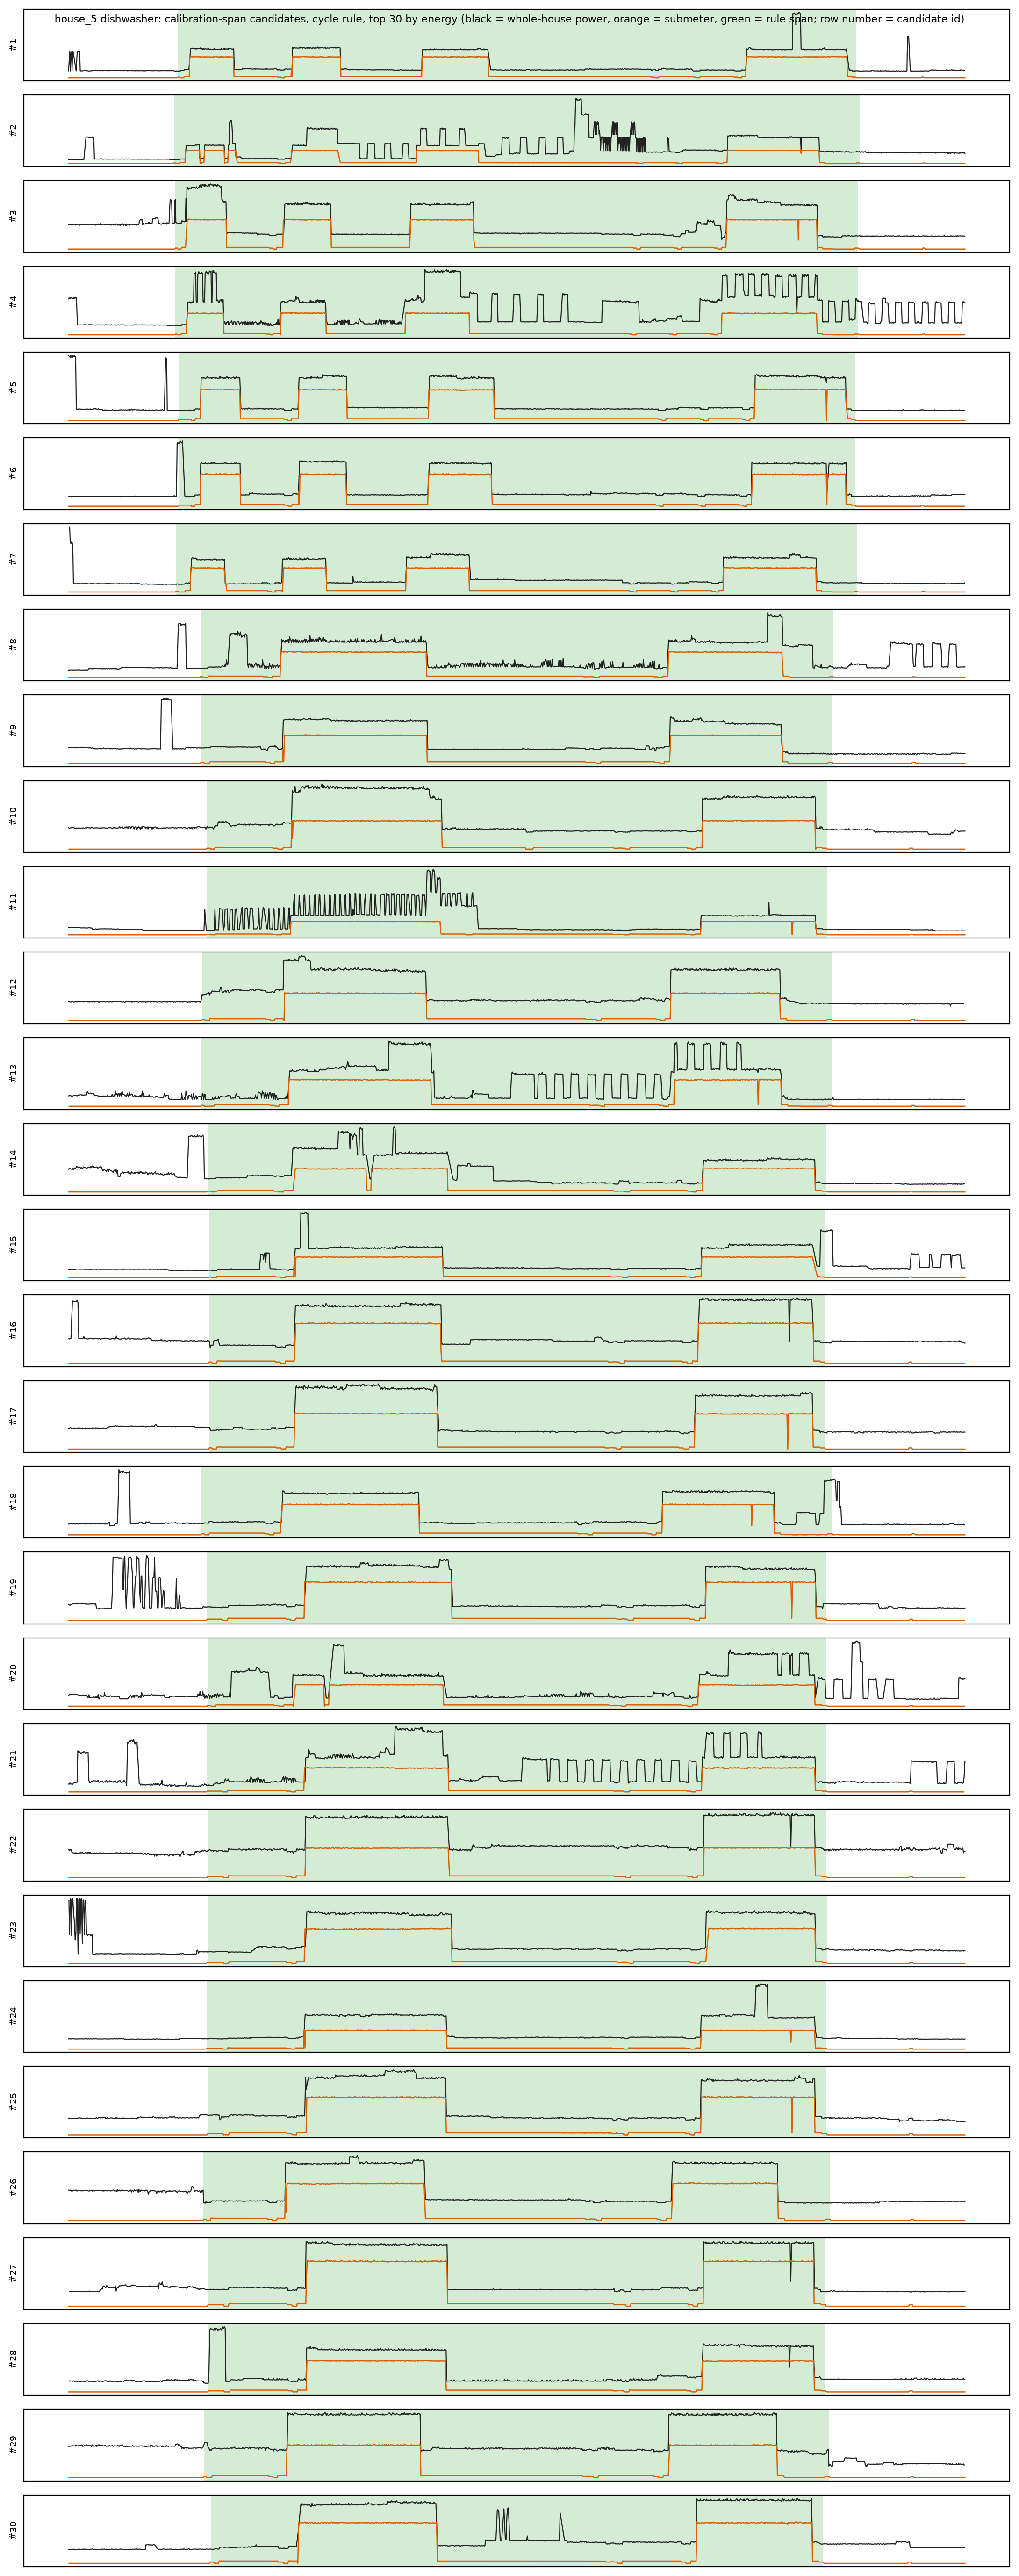

In [ ]:
# --- House 5 DW review sheet (fig) --------------------------------------
fig_h5_dw_sheet, h5_dw_sheet_info = sheet_fig("house_5", "dishwasher")
fig_h5_dw_sheet  # noqa: B018  (render figure as cell output)

In [ ]:
_rows = [
    [str(r["row"]), str(pd.to_datetime(r["t_on_us"], unit="us"))[:16], f"{r['dur_min']:.0f}", f"{r['wh']:.0f}"]
    for r in h5_dw_sheet_info
]
mo.md(
    "### House 5 dishwasher: review sheet\n\n"
    + bl.md_table(["row", "cycle start (UTC)", "dur (min)", "energy (Wh)"], _rows)
)

### House 5 dishwasher: review sheet

| row | cycle start (UTC) | dur (min) | energy (Wh) |
|---|---|---|---|
| 1 | 2014-08-27 12:01 | 124 | 1430 |
| 2 | 2014-09-03 18:01 | 130 | 1404 |
| 3 | 2014-06-30 19:23 | 128 | 1366 |
| 4 | 2014-07-08 18:18 | 128 | 1361 |
| 5 | 2014-07-03 09:03 | 123 | 1345 |
| 6 | 2014-07-11 14:16 | 123 | 1345 |
| 7 | 2014-07-19 13:39 | 127 | 1319 |
| 8 | 2014-08-13 12:56 | 96 | 1166 |
| 9 | 2014-10-06 19:59 | 95 | 1149 |
| 10 | 2014-08-19 20:06 | 90 | 1134 |
| 11 | 2014-10-05 11:26 | 90 | 1127 |
| 12 | 2014-09-12 20:51 | 94 | 1120 |
| 13 | 2014-09-17 13:52 | 95 | 1114 |
| 14 | 2014-08-10 10:18 | 89 | 1110 |
| 15 | 2014-07-06 12:45 | 87 | 1110 |
| 16 | 2014-07-13 20:01 | 88 | 1107 |
| 17 | 2014-09-25 22:13 | 87 | 1104 |
| 18 | 2014-08-29 10:00 | 95 | 1103 |
| 19 | 2014-10-02 11:08 | 89 | 1103 |
| 20 | 2014-07-22 10:14 | 89 | 1101 |
| 21 | 2014-09-19 08:25 | 89 | 1097 |
| 22 | 2014-08-24 19:01 | 89 | 1092 |
| 23 | 2014-09-06 09:39 | 89 | 1091 |
| 24 | 2014-08-30 18:08 | 89 | 1088 |
| 25 | 2014-10-09 11:12 | 89 | 1081 |
| 26 | 2014-08-22 19:56 | 93 | 1076 |
| 27 | 2014-09-14 09:49 | 88 | 1073 |
| 28 | 2014-08-16 18:44 | 88 | 1071 |
| 29 | 2014-09-29 18:44 | 92 | 1063 |
| 30 | 2014-09-09 11:55 | 86 | 1061 |

In [ ]:
# --- House 5 curated marks from the store (computation) -----------------
h5_runs = runs_of("house_5")
h5_cur_wm = curated("house_5", "washing_machine")
h5_cur_dw = curated("house_5", "dishwasher")
h5_feat_wm = cycle_features(h5_cur_wm, h5_runs) if h5_cur_wm is not None else None
h5_feat_dw = cycle_features(h5_cur_dw, h5_runs) if h5_cur_dw is not None else None

In [ ]:
# presentation: house 5 curated marks + mark-derived profile features
_parts = []
for _dev, _cur, _feat in (
    ("washing_machine", h5_cur_wm, h5_feat_wm),
    ("dishwasher", h5_cur_dw, h5_feat_dw),
):
    if _cur is None:
        _parts.append(
            f"**{_dev}**: no curated marks in the store yet - the review "
            "sheet above is the pending artifact. Curation appends to "
            "data/gold_annot/ukdale/house_5/manual_cycles.csv (source tag "
            "manual_review_v1) and this section fills on re-export."
        )
    else:
        _rows = [
            [
                str(_i + 1),
                str(pd.to_datetime(_r.t_on_us, unit="us"))[:16],
                f"{_r.dur_s / 60.0:.0f}",
                f"{_feat['dp_peak'].iloc[_i]:.0f}" if _feat is not None and _feat["dp_peak"].notna().iloc[_i] else "-",
            ]
            for _i, _r in enumerate(_cur.itertuples())
        ]
        _dp_ok = int(_feat["dp_peak"].notna().sum()) if _feat is not None else 0
        _parts.append(
            f"**{_dev}**: {len(_cur)} curated marks (source "
            f"{_cur['source'].iloc[0]}), all inside the calibration "
            "span.\n\n"
            + bl.md_table(["#", "t_on (UTC)", "dur (min)", "strongest in-cycle activation dP (W)"], _rows)
            + f"\n\n{_dp_ok} of {len(_cur)} marks have a detectable "
            "aggregate activation inside their span."
        )
mo.md("### Curated marks, house 5 (loaded from the store)\n\n" + "\n\n".join(_parts))

### Curated marks, house 5 (loaded from the store)

**washing_machine**: 20 curated marks (source manual_review_v1), all inside the calibration span.

| # | t_on (UTC) | dur (min) | strongest in-cycle activation dP (W) |
|---|---|---|---|
| 1 | 2014-07-05 08:26 | 260 | 4716 |
| 2 | 2014-09-10 15:48 | 197 | 3566 |
| 3 | 2014-09-26 09:59 | 200 | 3948 |
| 4 | 2014-07-22 09:30 | 215 | 4339 |
| 5 | 2014-09-11 11:27 | 199 | 2088 |
| 6 | 2014-09-18 23:03 | 128 | 1653 |
| 7 | 2014-09-05 12:08 | 166 | 2822 |
| 8 | 2014-07-01 20:49 | 132 | 1978 |
| 9 | 2014-08-14 09:02 | 149 | 2849 |
| 10 | 2014-09-10 19:39 | 179 | 1853 |
| 11 | 2014-08-13 10:06 | 148 | 2298 |
| 12 | 2014-08-13 12:59 | 150 | 3420 |
| 13 | 2014-10-02 08:40 | 140 | 2222 |
| 14 | 2014-09-14 14:22 | 80 | 5008 |
| 15 | 2014-07-09 09:53 | 113 | 2370 |
| 16 | 2014-08-06 19:14 | 64 | 1906 |
| 17 | 2014-10-06 16:08 | 129 | 4990 |
| 18 | 2014-06-29 17:37 | 79 | 3870 |
| 19 | 2014-07-30 14:50 | 68 | 1592 |
| 20 | 2014-07-25 08:49 | 58 | 4418 |

20 of 20 marks have a detectable aggregate activation inside their span.

**dishwasher**: 20 curated marks (source manual_review_v1), all inside the calibration span.

| # | t_on (UTC) | dur (min) | strongest in-cycle activation dP (W) |
|---|---|---|---|
| 1 | 2014-08-27 12:01 | 124 | 4533 |
| 2 | 2014-09-03 18:01 | 130 | 7549 |
| 3 | 2014-06-30 19:23 | 128 | 2394 |
| 4 | 2014-07-08 18:18 | 128 | 4149 |
| 5 | 2014-07-03 09:03 | 123 | 1810 |
| 6 | 2014-07-11 14:16 | 123 | 2835 |
| 7 | 2014-07-19 13:39 | 127 | 1958 |
| 8 | 2014-08-13 12:56 | 96 | 3420 |
| 9 | 2014-10-06 19:59 | 95 | 1904 |
| 10 | 2014-08-19 20:06 | 90 | - |
| 11 | 2014-09-12 20:51 | 94 | - |
| 12 | 2014-09-17 13:52 | 95 | 3573 |
| 13 | 2014-08-10 10:18 | 89 | 3584 |
| 14 | 2014-07-06 12:45 | 87 | 4535 |
| 15 | 2014-07-13 20:01 | 88 | 1940 |
| 16 | 2014-09-25 22:13 | 87 | 2105 |
| 17 | 2014-08-29 10:00 | 95 | 2428 |
| 18 | 2014-10-02 11:08 | 89 | 1973 |
| 19 | 2014-07-22 10:14 | 89 | 4037 |
| 20 | 2014-09-19 08:25 | 89 | 3701 |

18 of 20 marks have a detectable aggregate activation inside their span.

## Houses 3 and 4 - no program device, verification only

Neither house has a clean program-cycle appliance to curate: house 3
(39 days) has exactly one canonical device (the kettle); house 4's
washing machine shares a channel with a microwave and a breadmaker,
so no WM cycle GT can exist there. Both still get the rule store
files, and their burst channels are verified.

In [ ]:
# --- Houses 3-4 health + burst verification (computation) ---------------
brief_h34 = {}
for _h in ("house_3", "house_4"):
    _health = []
    for _name in ("mains",) + tuple(profiles_df.loc[profiles_df["house"] == _h, "device"]):
        _df = load_chan(_h, _name)
        _ts = _df["ts_us"].to_numpy(np.int64)
        d = np.diff(_ts) / 1e6
        d = d[(d > 0) & (d < 60)]
        _dt = float(np.median(d)) if d.size else float("nan")
        _health.append({"channel": _name, "rows": int(_ts.size), "modal_dt_s": _dt})
    brief_h34[_h] = {"health": _health}

In [ ]:
_parts = []
for _h in ("house_3", "house_4"):
    _rows = [
        [c["channel"], f"{c['rows']:,}", f"{c['modal_dt_s']:.1f}"]
        for c in brief_h34[_h]["health"]
    ]
    _prof = profiles_df[profiles_df["house"] == _h]
    _dev_rows = [
        [
            r["device"],
            str(r["class"]),
            r["thr_source"],
            f"{r['thr_used_w']:.0f}",
            f"{r['n_cycles']:,}",
            (r["notes"] if isinstance(r["notes"], str) and r["notes"] else "-"),
        ]
        for r in _prof.to_dict("records")
    ]
    _parts.append(
        f"### {_h}\n\n" + bl.md_table(["channel", "rows", "median dt (s)"], _rows)
        + "\n\n" + bl.md_table(["device", "class", "thr source", "thr used (W)", "cycles/episodes", "note"], _dev_rows)
    )
mo.md(
    "### Houses 3-4 device verification\n\n" + "\n\n".join(_parts)
    + "\n\nVerdicts. **House 3**: kettle only (55 boils, p50 1.8 min, "
    "94 Wh - healthy burst channel); no program device, no curation. "
    "**House 4**: kettle healthy (674 boils); the 'microwave' channel "
    "is the shared washing_machine + microwave + breadmaker circuit - "
    "its 90.5 W episodes mix washer pumps and breadmaker kneads into "
    "'microwave' time, so it is excluded from burst GT rather than "
    "curated; fridge is duty (reference only). No program device in "
    "either house - the program-cycle curation surface stays houses "
    "1, 2 and 5."
)

### Houses 3-4 device verification

### house_3

| channel | rows | median dt (s) |
|---|---|---|
| mains | 512,327 | 6.0 |
| kettle | 515,845 | 6.0 |

| device | class | thr source | thr used (W) | cycles/episodes | note |
|---|---|---|---|---|---|
| kettle | burst | gold | 1475 | 55 | - |

### house_4

| channel | rows | median dt (s) |
|---|---|---|
| mains | 2,186,446 | 6.0 |
| kettle | 2,171,770 | 6.0 |
| microwave | 2,180,830 | 6.0 |
| fridge | 2,194,864 | 6.0 |

| device | class | thr source | thr used (W) | cycles/episodes | note |
|---|---|---|---|---|---|
| kettle | burst | gold | 1083 | 674 | - |
| microwave | burst | excluded | 90 | 0 | mixed channel (washing_machine_microwave_breadmaker): contaminated by WM and breadmaker activations; not usable as microwave GT |
| fridge | duty | gold | 46 | 4,828 | - |

Verdicts. **House 3**: kettle only (55 boils, p50 1.8 min, 94 Wh - healthy burst channel); no program device, no curation. **House 4**: kettle healthy (674 boils); the 'microwave' channel is the shared washing_machine + microwave + breadmaker circuit - its 90.5 W episodes mix washer pumps and breadmaker kneads into 'microwave' time, so it is excluded from burst GT rather than curated; fridge is duty (reference only). No program device in either house - the program-cycle curation surface stays houses 1, 2 and 5.

In [ ]:
# --- Store inventory (computation) ---------------------------------------
inv_rows = []
for _h in ("house_1", "house_2", "house_3", "house_4", "house_5"):
    _row = {"house": _h}
    try:
        _c = pd.read_csv(bl.gold_annot_file(cfg["dataset"], _h, "manual_cycles"))
        _row["cycles_rows"] = int(len(_c))
        _row["cycles_sources"] = ",".join(sorted(_c["source"].astype(str).unique())) if len(_c) else "-"
    except FileNotFoundError:
        _row["cycles_rows"] = 0
        _row["cycles_sources"] = "-"
    try:
        _r = pd.read_csv(bl.gold_annot_file(cfg["dataset"], _h, "rule_cycles"))
        _row["rule_cycles_rows"] = int(len(_r))
    except pd.errors.EmptyDataError:
        _row["rule_cycles_rows"] = 0
    _p = pd.read_csv(bl.gold_annot_file(cfg["dataset"], _h, "device_profile"))
    _row["profile_rows"] = int(len(_p))
    inv_rows.append(_row)
inventory_df = pd.DataFrame(inv_rows)

In [ ]:
_rows = [
    [
        r.house,
        f"{r.cycles_rows:,}",
        r.cycles_sources,
        f"{r.rule_cycles_rows:,}",
        f"{r.profile_rows:,}",
    ]
    for r in inventory_df.itertuples()
]
mo.md(
    "## The gold_annot store after this round\n\n"
    + bl.md_table(
        ["house", "manual_cycles.csv rows (manual marks)", "sources", "rule_cycles.csv rows (burst)", "device_profile.csv rows"],
        _rows,
    )
    + "\n\nDivision of labor, now per house: **manual_cycles.csv** holds only "
    "hand-curated program-device marks (the manual fallback, append-"
    "only, source-tagged); **rule_cycles.csv** holds the derivable "
    "burst cycles (kettle everywhere; microwave in houses 1-2 only, "
    "for the reasons above); **device_profile.csv** holds the class + "
    "measured power/energy summary per device (the numbers a product "
    "would quote a user); **splits.csv** holds the reserved test span. "
    "Everything regenerates from 02_build_rule_profiles.py except the "
    "manual marks, which are the point."
)

## The gold_annot store after this round

| house | manual_cycles.csv rows (manual marks) | sources | rule_cycles.csv rows (burst) | device_profile.csv rows |
|---|---|---|---|---|
| house_1 | 20 | manual_review_v1 | 11,944 | 5 |
| house_2 | 40 | manual_review_v1 | 1,132 | 5 |
| house_3 | 0 | - | 55 | 1 |
| house_4 | 0 | - | 674 | 3 |
| house_5 | 40 | manual_review_v1 | 186 | 5 |

Division of labor, now per house: **manual_cycles.csv** holds only hand-curated program-device marks (the manual fallback, append-only, source-tagged); **rule_cycles.csv** holds the derivable burst cycles (kettle everywhere; microwave in houses 1-2 only, for the reasons above); **device_profile.csv** holds the class + measured power/energy summary per device (the numbers a product would quote a user); **splits.csv** holds the reserved test span. Everything regenerates from 02_build_rule_profiles.py except the manual marks, which are the point.

## Findings

1. **The gold thresholds are not uniformly usable for cycle GT** - and
this is the round's main catch. Four thresholds were overridden or
excluded on measured evidence: house_5 washing_machine 7.5 W (standby
noise; produced 9 day-scale "cycles"), house_2 dishwasher 984 W
(heater-only - shatters programs), house_2 microwave 13 W (below
standby), house_2 fridge 5.5 W (standby). Two channels were excluded
outright: house_5 microwave (constant ~50 W - no appliance signal) and
house_4 microwave (shared WM+MW+breadmaker circuit). Every decision is
recorded in device_profile.csv (thr_source, notes) and re-verified on
the busiest-day overlays.
2. **The class split carries across houses unchanged.** Program
devices need 600 s/600 s; bursts keep raw episodes (all kettle
channels verified healthy: p50 1.7-2.8 min, max 11 min); fridge stays
duty (excluded). No house needed a different dwell/merge.
3. **Cycle counts per house are small enough to curate and big enough
to matter**: house_2 WM 36 cal-span candidates (p50 40 min - a
genuinely different household from house_1's 91 min), house_2 DW 66
(p50 47 min), house_5 WM 85 (p50 75 min), house_5 DW 38 (p50 90 min).
20 marks per device-house is 8-53% of the calibration pool - the
profile inputs are a real sample, not a tail.
4. **Curation surface**: houses 1, 2 and 5 (WM + DW where present);
houses 3 and 4 have no clean program device - recorded, not forced.
5. **Whole-house context is part of the curation contract now**: every
sheet strip shows the aggregate above the submeter, so a candidate is
kept only when the cycle is recognizable in house context - the
property that actually matters for mark-based detection downstream.